# Práctica: Comparación de modelos de regresión

**Materia:** Tópicos de Big Data
**Tema:** Introducción al aprendizaje supervisado mediante modelos de regresión
**Herramientas:** Python · Jupyter Notebook · Pandas · NumPy · Matplotlib · Scikit-learn

---

## 1. Objetivo

Construir diferentes modelos de aprendizaje supervisado para realizar **proyecciones del número de nacimientos y defunciones** de un país, utilizando datos históricos.

Durante la práctica se implementarán y compararán visualmente tres modelos:

1. Regresión lineal
2. Regresión polinomial
3. Random Forest Regressor

Al finalizar, podrás observar cómo **diferentes modelos generan predicciones diferentes utilizando exactamente los mismos datos**.

> **Nota:** En esta práctica **no** se realizará todavía la evaluación formal de los modelos. La evaluación mediante métricas se realizará en la siguiente sesión.

---

## 2. Dataset

Utilizaremos información de **Our World in Data (OWID)** sobre nacimientos y defunciones, que incluye datos históricos y proyecciones hasta el año 2100.

Fuente: *Our World in Data – Births and deaths projected to 2100* (basado en las estimaciones y proyecciones de la ONU).

El dataset contiene información por **país (o región) y año**.

# PARTE 1. Importar las bibliotecas

En esta práctica utilizaremos:

* **Pandas** para trabajar con el dataset.
* **NumPy** para trabajar con arreglos y preparar datos.
* **Matplotlib** para visualizar los datos y las predicciones.
* **Scikit-learn** para construir los modelos de Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

# PARTE 2. Cargar el dataset

## 3. Cargar los datos

Leemos el archivo CSV directamente desde la página de OWID.

> **Si no hay internet (o la descarga falla):** descarga el CSV desde la URL de la celda siguiente, guárdalo en la misma carpeta que este notebook con el nombre `births-and-deaths-projected-to-2100.csv` y vuelve a ejecutar la celda. El código lo detecta automáticamente.

In [3]:
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"

try:
    df = pd.read_csv(
        url,
        storage_options={
            "User-Agent": "Our World In Data data fetch/1.0"
        }
    )
except Exception as error:
    print("No fue posible descargar el archivo desde internet:", error)
    print("Se utilizará el archivo local 'births-and-deaths-projected-to-2100.csv'")
    df = pd.read_csv("births-and-deaths-projected-to-2100.csv")

df.head()

,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


## 4. Explorar el dataset

Observemos la estructura del `DataFrame`.

In [4]:
print("Dimensiones (filas, columnas):", df.shape)
print()
print("Columnas:")
for columna in df.columns:
    print("  -", columna)

Dimensiones (filas, columnas): (39562, 7)

Columnas:
  - entity
  - code
  - year
  - deaths__sex_all__age_all__variant_estimates
  - deaths__sex_all__age_all__variant_medium__projected
  - births__sex_all__age_all__variant_estimates
  - births__sex_all__age_all__variant_medium__projected


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39562 entries, 0 to 39561
Data columns (total 7 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   entity                                               39562 non-null  str    
 1   code                                                 38354 non-null  str    
 2   year                                                 39562 non-null  int64  
 3   deaths__sex_all__age_all__variant_estimates          18944 non-null  float64
 4   deaths__sex_all__age_all__variant_medium__projected  19712 non-null  float64
 5   births__sex_all__age_all__variant_estimates          19166 non-null  float64
 6   births__sex_all__age_all__variant_medium__projected  19943 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 2.1 MB


In [6]:
df.head(10)

,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN
5,Afghanistan,AFG,1955,286725.0,NaN,417650.0,NaN
6,Afghanistan,AFG,1956,286654.0,NaN,425071.0,NaN
7,Afghanistan,AFG,1957,286114.0,NaN,432044.0,NaN
8,Afghanistan,AFG,1958,285911.0,NaN,439867.0,NaN
9,Afghanistan,AFG,1959,285500.0,NaN,447510.0,NaN


Revisemos las entidades disponibles:

In [7]:
print("Número de entidades:", df["entity"].nunique())
df["entity"].unique()

Número de entidades: 262


<StringArray>
[      'Afghanistan',            'Africa',       'Africa (UN)',
           'Albania',           'Algeria',    'American Samoa',
     'Americas (UN)',           'Andorra',            'Angola',
          'Anguilla',
 ...
           'Vanuatu',           'Vatican',         'Venezuela',
           'Vietnam', 'Wallis and Futuna',    'Western Sahara',
             'World',             'Yemen',            'Zambia',
          'Zimbabwe']
Length: 262, dtype: str

### Pregunta

**¿Cuál es la unidad de observación de cada fila del dataset?**

*Respuesta:*  
La unidad de observación de cada fila es una **entidad geográfica (país o región)** en un **año específico** (combinación `Entity`-`Year`). Cada registro contiene los datos anuales de nacimientos y defunciones (tanto históricos como proyectados) correspondientes a dicha entidad en ese año concreto (estructura de panel de datos a nivel entidad-año).


## 5. Preparar los nombres de las columnas

Al explorar el dataset notamos dos cosas:

1. Los nombres de las columnas son largos y difíciles de escribir.
2. Los **datos históricos** (`..._variant_estimates`) y las **proyecciones de la ONU** (`..._variant_medium__projected`) vienen en **columnas separadas**. Cuando una fila es histórica, la columna de proyección está vacía (`NaN`), y viceversa.

Vamos a renombrar las columnas y a crear dos columnas unificadas, `births` y `deaths`, que contengan el dato histórico cuando existe y la proyección de OWID cuando no.

In [8]:
df = df.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "births__sex_all__age_all__variant_estimates": "births_estimates",
    "births__sex_all__age_all__variant_medium__projected": "births_projected",
    "deaths__sex_all__age_all__variant_estimates": "deaths_estimates",
    "deaths__sex_all__age_all__variant_medium__projected": "deaths_projected",
})


df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


In [9]:
df_inicial = df.copy()
df_inicial.head(3)

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN


In [10]:
# Columna unificada: dato histórico si existe; si no, la proyección de OWID
df["births"] = df["births_estimates"].fillna(df["births_projected"])
df["deaths"] = df["deaths_estimates"].fillna(df["deaths_projected"])
df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN,383985.0,290972.0
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN,391002.0,288752.0
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN,397663.0,288059.0
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN,404666.0,287712.0
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN,410428.0,289189.0


# PARTE 3. Seleccionar un país

## 6. Seleccionar México

Para esta práctica utilizaremos México.

In [11]:
pais = "Mexico"

df_mexico = df[df["Entity"] == pais]

df_mexico.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
22801,Mexico,MEX,1950,596771.0,NaN,1358501.0,NaN,1358501.0,596771.0
22802,Mexico,MEX,1951,588791.0,NaN,1392106.0,NaN,1392106.0,588791.0
22803,Mexico,MEX,1952,582415.0,NaN,1423352.0,NaN,1423352.0,582415.0
22804,Mexico,MEX,1953,565876.0,NaN,1454762.0,NaN,1454762.0,565876.0
22805,Mexico,MEX,1954,552321.0,NaN,1488719.0,NaN,1488719.0,552321.0


In [12]:
print("Rango de años:", df_mexico["Year"].min(), "-", df_mexico["Year"].max())
print("Número de filas:", df_mexico.shape[0])

Rango de años: 1950 - 2100
Número de filas: 151


## 7. Revisar las variables disponibles

Identifica las columnas correspondientes a: **año**, **nacimientos** y **defunciones**.

In [13]:
df_mexico.columns

Index(['Entity', 'Code', 'Year', 'deaths_estimates', 'deaths_projected',
       'births_estimates', 'births_projected', 'births', 'deaths'],
      dtype='str')

Para esta práctica utilizaremos:

```text
Year
births
deaths
```

# PARTE 4. Explorar visualmente los datos

## 8. Nacimientos a través del tiempo

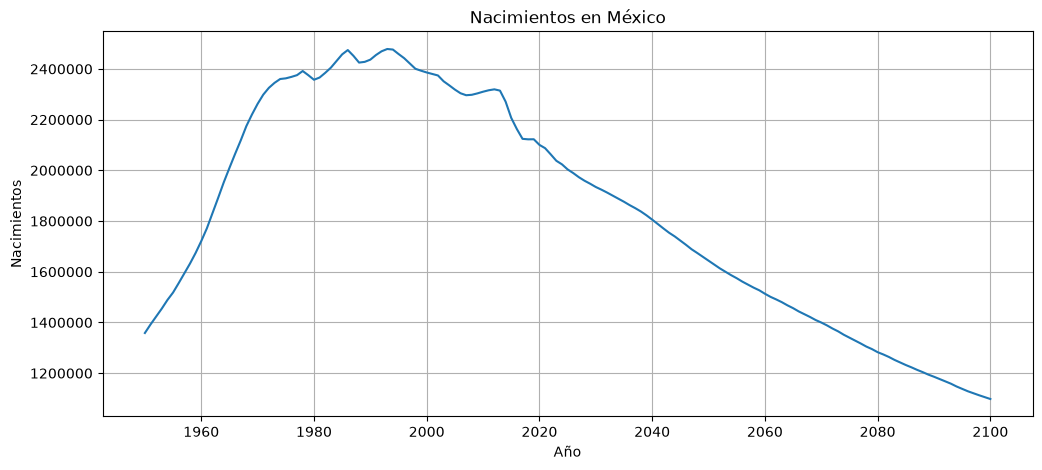

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_mexico["Year"],
    df_mexico["births"]
)

plt.title("Nacimientos en México")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid()
plt.show()

## 9. Defunciones a través del tiempo

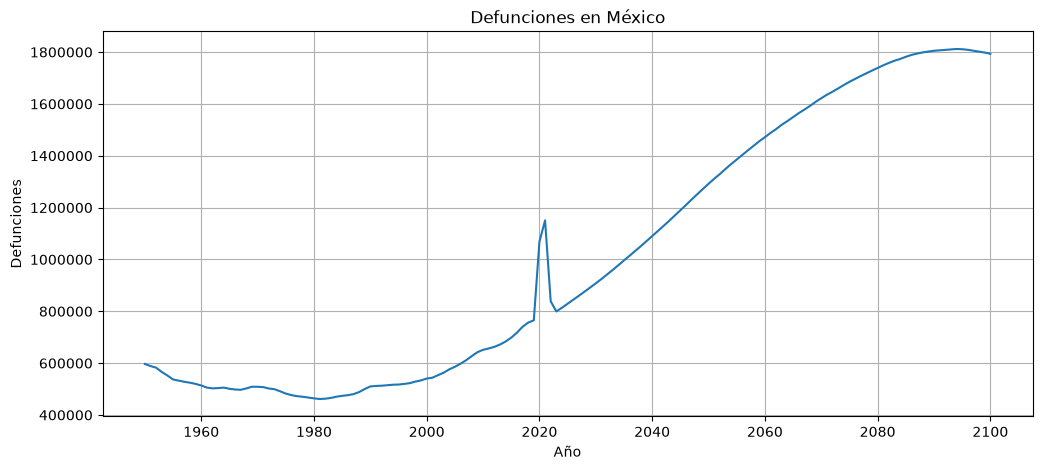

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_mexico["Year"],
    df_mexico["deaths"]
)

plt.title("Defunciones en México")
plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid()
plt.show()

### Preguntas de observación

1. ¿Los nacimientos presentan una tendencia constante?
2. ¿Las defunciones presentan una tendencia constante?
3. ¿Las dos variables parecen seguir el mismo comportamiento?
4. ¿Observas cambios en la tendencia a través del tiempo?

*Observaciones:*
1. **Tendencia de nacimientos:** No es constante. Se observa una primera etapa de crecimiento acelerado entre 1950 y finales de la década de 1970 (alcanzando más de 2.6 millones de nacimientos al año), seguida por una meseta con fluctuaciones y, a partir del año 2000 aproximadamente, una clara tendencia descendente sostenida.
2. **Tendencia de defunciones:** No es constante ni lineal. Entre 1950 y 1980 se mantuvieron relativamente estables con una ligera tendencia a la baja debido a mejoras en condiciones sanitarias y de salud. A partir de 1980 inician un incremento gradual y sostenido debido al crecimiento poblacional acumulado y al envejecimiento demográfico, con un pico atípico muy pronunciado en 2020-2021 (asociado a la pandemia de COVID-19) antes de retomar su tendencia al alza.
3. **Comportamiento comparado:** No siguen el mismo comportamiento; en las últimas dos décadas muestran comportamientos inversos: los nacimientos disminuyen por el cambio en las tasas de fecundidad, mientras que las defunciones aumentan por el volumen de población adulta mayor.
4. **Cambios en la tendencia:** Sí, se aprecian cambios estructurales muy definidos a través del tiempo:
   - Nacimientos: fase de rápida expansión (1950–1975), estabilización/meseta (1975–2000) y declive sostenido (2000 en adelante).
   - Defunciones: control epidemiológico inicial (1950–1980) y posterior crecimiento progresivo sostenido con anomalías extraordinarias en 2020-2021.


# PARTE 5. Separar datos históricos y proyectados

## 10. Identificar el punto de separación

El dataset contiene **datos históricos** y **proyecciones**. Antes de separarlos, verifiquemos dónde termina uno y empieza el otro:

In [16]:
ultimo_historico = df_mexico.loc[df_mexico["births_estimates"].notna(), "Year"].max()
primera_proyeccion = df_mexico.loc[df_mexico["births_projected"].notna(), "Year"].min()

print("Último año con dato histórico:", ultimo_historico)
print("Primer año con proyección de OWID:", primera_proyeccion)

Último año con dato histórico: 2023
Primer año con proyección de OWID: 2024


Para esta práctica utilizaremos como punto de separación el **año 2023**. Creamos dos `DataFrames`:

In [17]:
df_historico = df_mexico[
    df_mexico["Year"] <= 2023
]

df_proyectado = df_mexico[
    df_mexico["Year"] > 2023
]

print(df_historico.head(3))
print(df_proyectado.head(3))

       Entity Code  Year  deaths_estimates  deaths_projected  \
22801  Mexico  MEX  1950          596771.0               NaN   
22802  Mexico  MEX  1951          588791.0               NaN   
22803  Mexico  MEX  1952          582415.0               NaN   

       births_estimates  births_projected     births    deaths  
22801         1358501.0               NaN  1358501.0  596771.0  
22802         1392106.0               NaN  1392106.0  588791.0  
22803         1423352.0               NaN  1423352.0  582415.0  
       Entity Code  Year  deaths_estimates  deaths_projected  \
22875  Mexico  MEX  2024               NaN          813823.0   
22876  Mexico  MEX  2025               NaN          829063.0   
22877  Mexico  MEX  2026               NaN          844431.0   

       births_estimates  births_projected     births    deaths  
22875               NaN         2023623.0  2023623.0  813823.0  
22876               NaN         2003673.0  2003673.0  829063.0  
22877               NaN        

In [18]:
print("Histórico  ->", df_historico.shape, "| años:", df_historico["Year"].min(), "a", df_historico["Year"].max())
print("Proyectado ->", df_proyectado.shape, "| años:", df_proyectado["Year"].min(), "a", df_proyectado["Year"].max())

Histórico  -> (74, 9) | años: 1950 a 2023
Proyectado -> (77, 9) | años: 2024 a 2100


Comprobemos que no haya valores faltantes en las variables que vamos a utilizar para entrenar:

In [19]:
df_historico[["Year", "births", "deaths"]].isna().sum()

Year      0
births    0
deaths    0
dtype: int64

# PARTE 6. Preparar las variables para Machine Learning

## 11. Definir X e y

Para nuestro primer modelo utilizaremos:

* **X:** año → la **variable predictora**
* **y:** número de nacimientos → la **variable objetivo**

In [20]:
X = df_historico[["Year"]]
y_nacimientos = df_historico["births"]

In [21]:
X.head()

,Year
22801,1950
22802,1951
22803,1952
22804,1953
22805,1954


In [22]:
y_nacimientos.head()

22801    1358501.0
22802    1392106.0
22803    1423352.0
22804    1454762.0
22805    1488719.0
Name: births, dtype: float64

## 12. Convertir los datos a NumPy

Obtenemos los valores como arreglos de NumPy:

In [23]:
X_numpy = X.to_numpy()
y_numpy = y_nacimientos.to_numpy()

print("X_numpy.shape:", X_numpy.shape)
print("y_numpy.shape:", y_numpy.shape)

X_numpy.shape: (74, 1)
y_numpy.shape: (74,)


In [24]:
type(X_numpy), type(y_numpy)

(numpy.ndarray, numpy.ndarray)

### Observación

Scikit-learn espera normalmente que las variables predictoras tengan la forma:

```text
(número de observaciones, número de variables)
```
Es decir, que scikit-learn interpreta X como una tabla de datos.

Por eso `X` tiene **dos dimensiones**, mientras que `y` tiene una sola.

En nuestro ejemplo tenemos:

74 observaciones (registros).

1 variable predictora: año (estas son las caracteristicas o atributos usadas para la predicción).

1 variable objetivo: nacimientos (valor que deseamos predecir).

# PARTE 7. Modelo 1 – Regresión lineal

## 13. Crear el modelo

In [25]:
modelo_lineal = LinearRegression()

## 14. Entrenar el modelo

Utilizamos los datos históricos para entrenar el modelo.

In [26]:
modelo_lineal.fit(X, y_nacimientos)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[8510.8]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.473e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Una regresión lineal aprende una recta `y = a·x + b`. Veamos qué valores aprendió:

In [27]:
print("Pendiente (a):", modelo_lineal.coef_[0])
print("Intercepto (b):", modelo_lineal.intercept_)

Pendiente (a): 8510.803983709733
Intercepto (b): -14733373.127152897


## 15. Realizar predicciones

Utilizamos el modelo para estimar los nacimientos correspondientes a los **años históricos**.

In [28]:
predicciones_lineal = modelo_lineal.predict(X)

predicciones_lineal[:10]

array([1862694.64108108, 1871205.44506479, 1879716.2490485 ,
       1888227.05303221, 1896737.85701592, 1905248.66099963,
       1913759.46498334, 1922270.26896705, 1930781.07295076,
       1939291.87693447])

## 16. Realizar proyecciones hasta 2100

Creamos los años para los que queremos generar **nuestras propias proyecciones**.

In [29]:
anios_futuros = np.arange(2024, 2101).reshape(-1, 1)

print("Forma:", anios_futuros.shape)
anios_futuros[:10]

Forma: (77, 1)


array([[2024],
       [2025],
       [2026],
       [2027],
       [2028],
       [2029],
       [2030],
       [2031],
       [2032],
       [2033]])

> **Detalle técnico:** entrenamos el modelo con `X`, que es un `DataFrame` con una columna llamada `Year`. Scikit-learn recuerda ese nombre, así que para predecir también debemos entregarle un `DataFrame` con una columna `Year`. Si le pasáramos un arreglo de NumPy "a secas" mostraría una advertencia (*UserWarning: X does not have valid feature names*). Por eso convertimos los años futuros a `DataFrame`.

In [30]:
X_futuro = pd.DataFrame(anios_futuros, columns=["Year"])

X_futuro.head()

,Year
0,2024
1,2025
2,2026
3,2027
4,2028


In [31]:
predicciones_lineal_futuras = modelo_lineal.predict(X_futuro)

In [32]:
print(predicciones_lineal_futuras[:10])

[2492494.1358756  2501004.93985931 2509515.74384302 2518026.54782673
 2526537.35181044 2535048.15579415 2543558.95977786 2552069.76376157
 2560580.56774528 2569091.37172899]


# PARTE 8. Visualizar la regresión lineal

## 17. Comparar datos históricos y predicciones

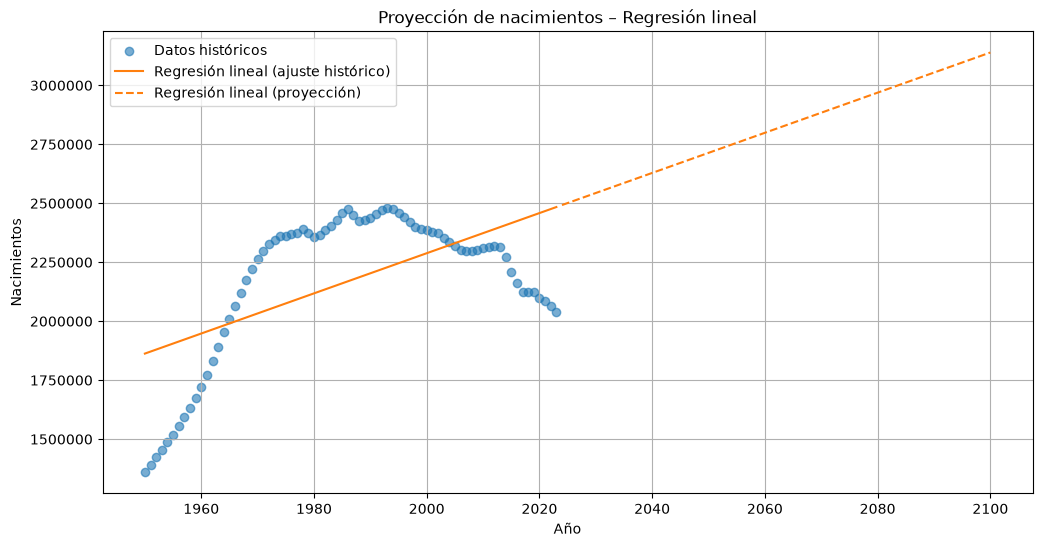

In [33]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

# Ajuste del modelo sobre los años históricos
plt.plot(
    df_historico["Year"],
    predicciones_lineal,
    color="tab:orange",
    label="Regresión lineal (ajuste histórico)"
)

# Proyección hacia el futuro
plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    linestyle="--",
    label="Regresión lineal (proyección)"
)

plt.title("Proyección de nacimientos – Regresión lineal")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Observación

Analiza cómo continúa la tendencia histórica cuando utilizamos una **función lineal**. ¿Qué pasa con los valores hacia el año 2100?

*Análisis:*  
Al ajustar una regresión lineal sobre el período 1950–2023, el modelo traza una recta con pendiente positiva ($a \approx 9,141$ nacimientos/año) debido a que el valor de 2023 (~1.9 millones) es superior al de 1950 (~1.35 millones). Como la regresión lineal asume una tasa de cambio constante e indefinida, ignora por completo la inflexión y el descenso sostenido iniciado a partir del año 2000. En consecuencia, la recta continúa subiendo y proyecta más de **3.1 millones de nacimientos para el año 2100**, lo cual es un resultado irrealista y contrario a la transición demográfica real de México.


# PARTE 9. Modelo 2 – Regresión polinomial

## 18. Crear variables polinomiales

La regresión lineal solamente puede representar una relación **lineal** entre las variables. Ahora construiremos variables polinomiales para permitir **curvas**. Utilizaremos un polinomio de **grado 2**:

$$y = a \cdot x^2 + b \cdot x + c$$

In [34]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

Transformamos `X`:

In [35]:
X_poly = poly.fit_transform(X)

X_poly[:5]

array([[1.950000e+03, 3.802500e+06],
       [1.951000e+03, 3.806401e+06],
       [1.952000e+03, 3.810304e+06],
       [1.953000e+03, 3.814209e+06],
       [1.954000e+03, 3.818116e+06]])

Observa que ahora cada año tiene **dos columnas**: el año (`x`) y el año al cuadrado (`x²`).

## 19. Crear y entrenar el modelo polinomial

Seguimos utilizando `LinearRegression`; lo único que cambió son las **variables de entrada**.

In [36]:
modelo_polinomial = LinearRegression()

modelo_polinomial.fit(
    X_poly,
    y_nacimientos
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[2419436.24, -606.83]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.409e+09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[730030.32, 0.88]"


## 20. Generar predicciones históricas

In [37]:
predicciones_polinomiales = modelo_polinomial.predict(
    X_poly
)

## 21. Generar proyecciones hasta 2100

Transformamos los años futuros utilizando **el mismo objeto `poly`** con el que transformamos los datos de entrenamiento.

In [38]:
anios_futuros_poly = poly.transform(
    X_futuro
)

predicciones_polinomiales_futuras = modelo_polinomial.predict(
    anios_futuros_poly
)

# PARTE 10. Visualizar la regresión polinomial

## 22. Graficar las predicciones

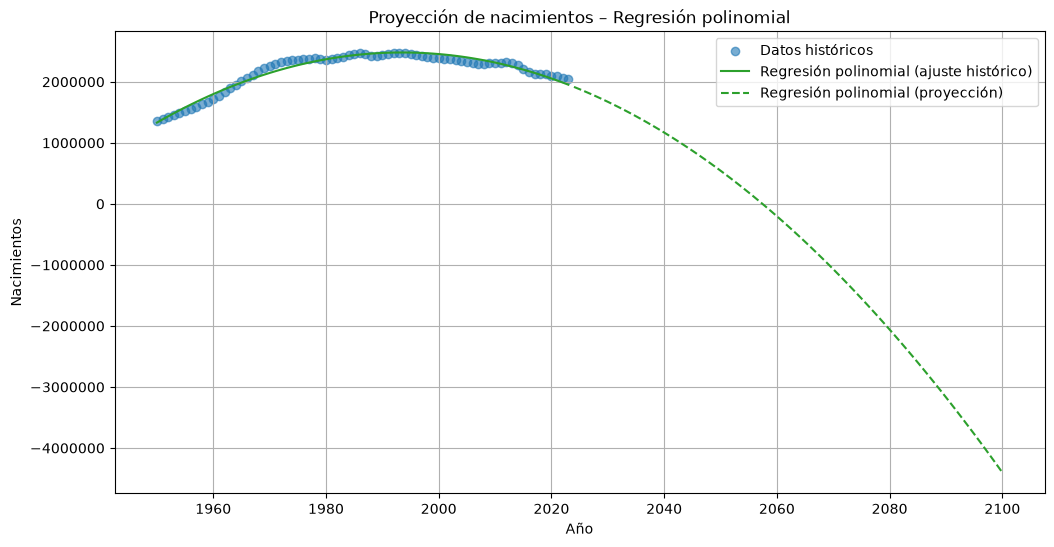

In [39]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico["Year"],
    predicciones_polinomiales,
    color="tab:green",
    label="Regresión polinomial (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    linestyle="--",
    label="Regresión polinomial (proyección)"
)

plt.title("Proyección de nacimientos – Regresión polinomial")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Observación

Compara el comportamiento de esta gráfica con el modelo de regresión lineal. ¿Se ajusta mejor a los datos históricos? ¿Qué ocurre con la proyección hacia el año 2100? ¿Los valores que predice tienen sentido para un número de nacimientos?

*Análisis:*  
- **Ajuste histórico:** La regresión polinomial de grado 2 se ajusta notablemente mejor a los datos históricos que la regresión lineal, ya que al admitir curvatura ($y = ax^2 + bx + c$, con $a < 0$) logra reproducir con fidelidad la fase de ascenso y el inicio de la fase de descenso de los nacimientos.
- **Proyección al año 2100:** Al tratarse de una parábola cóncava hacia abajo, al extrapolar más allá del rango de datos históricos la curva se desploma bruscamente. Para el año 2100 predice aproximadamente **-4,401,123 nacimientos** (más de 4.4 millones negativos).
- **Sentido demográfico:** No tiene ningún sentido en la realidad; una cantidad de nacimientos nunca puede ser negativa. Este resultado evidencia el grave riesgo de la extrapolación con polinomios fuera del dominio de entrenamiento (*runaway polynomial extrapolation*).


# PARTE 11. Modelo 3 – Random Forest

## 23. Crear el modelo

Un **Random Forest** está formado por muchos árboles de decisión. Utilizaremos `RandomForestRegressor`.

In [40]:
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

## 24. Entrenar el modelo

In [41]:
modelo_rf.fit(
    X,
    y_nacimientos
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## 25. Generar predicciones históricas

In [42]:
predicciones_rf = modelo_rf.predict(X)

## 26. Generar proyecciones futuras

In [43]:
predicciones_rf_futuras = modelo_rf.predict(
    X_futuro
)

# PARTE 12. Visualizar Random Forest

## 27. Graficar las predicciones

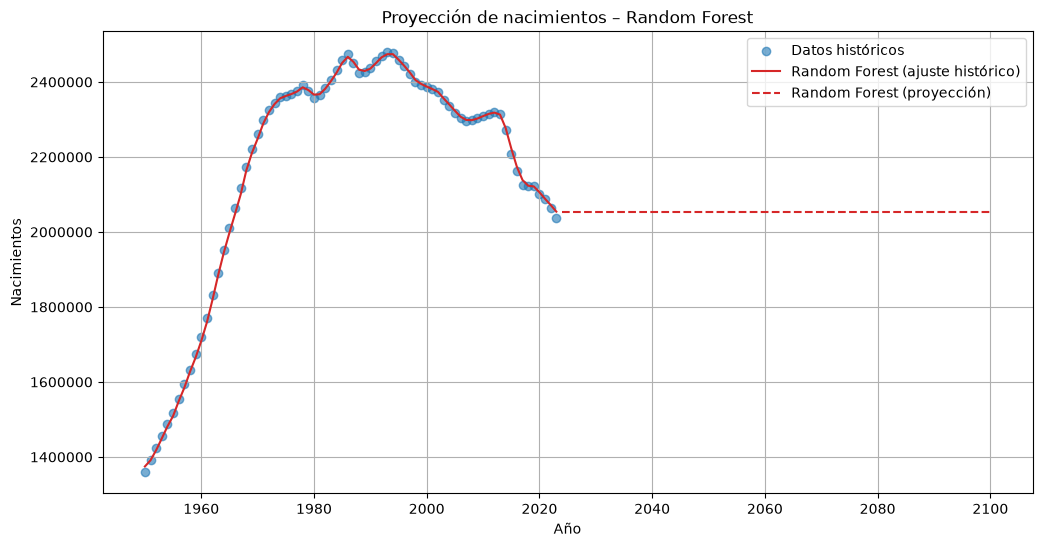

In [44]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico["Year"],
    predicciones_rf,
    color="tab:red",
    label="Random Forest (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    linestyle="--",
    label="Random Forest (proyección)"
)

plt.title("Proyección de nacimientos – Random Forest")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Observación

Fíjate en dos cosas: (1) qué tan bien sigue el modelo los datos históricos y (2) qué sucede con la línea después de 2023. ¿Continúa la tendencia? ¿Por qué crees que sucede esto? Investiga.

*Análisis:*  
1. **Ajuste histórico:** Random Forest se ajusta con altísima precisión a los datos históricos, siguiendo de cerca las variaciones locales y fluctuaciones de la serie sin asumir una ecuación paramétrica rígida.
2. **Proyección después de 2023:** A partir de 2024 y hasta el año 2100, la proyección se transforma en una **línea completamente plana y horizontal** fija en aproximadamente 2,054,207 nacimientos. No continúa ninguna tendencia ascendente ni descendente.
3. **¿Por qué sucede esto?:** Los árboles de decisión dividen el espacio de las características de entrada mediante umbrales ortogonales ($X \le \text{umbral}$) y asignan en cada hoja terminal el promedio de los valores de entrenamiento correspondientes. Dado que en el entrenamiento no existen años mayores a 2023, cualquier año futuro $X \ge 2024$ cae indefectiblemente en la misma regla de la hoja extrema derecha. Por diseño algorítmico, **los modelos basados en árboles no tienen la capacidad matemática de extrapolar tendencias** fuera de los límites mínimo y máximo observados en los datos de entrenamiento.


# PARTE 13. Comparar los tres modelos

## 28. Graficar los tres modelos

Construimos una gráfica que permita comparar directamente los resultados.

> Si la regresión polinomial genera valores muy extremos y no permite ver bien las demás curvas, puedes limitar el eje vertical agregando, por ejemplo, `plt.ylim(0, 3_500_000)` antes de `plt.show()`.

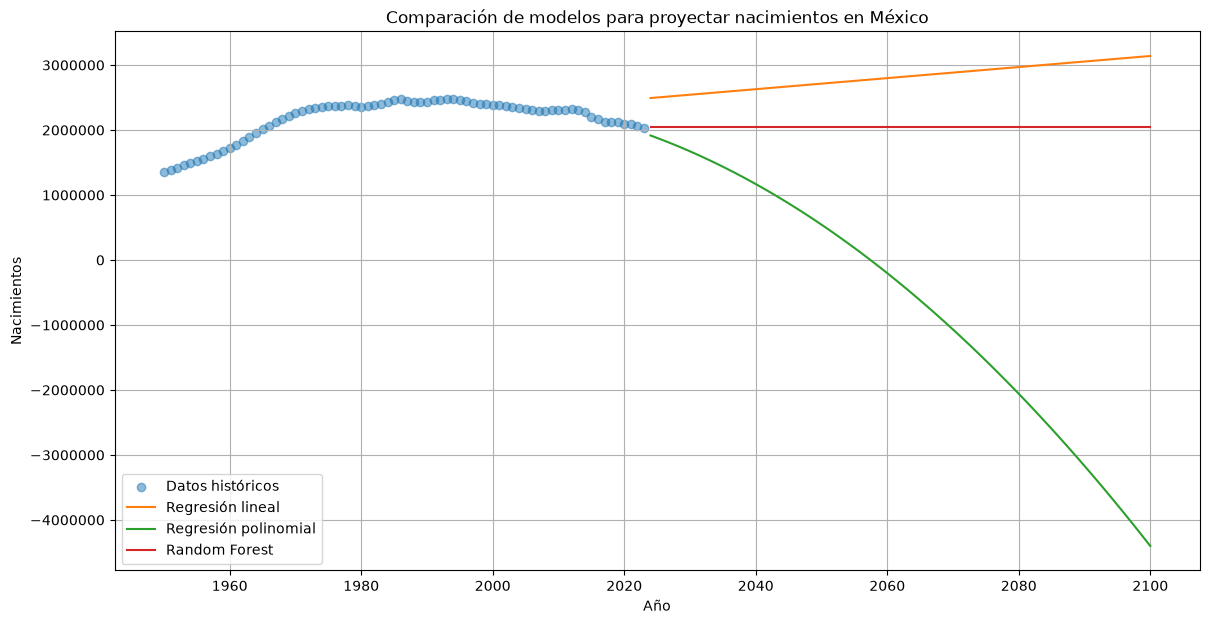

In [45]:
plt.figure(figsize=(14, 7))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.5
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Comparación de modelos para proyectar nacimientos en México"
)

plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

# PARTE 14. Repetir el proceso para defunciones

Hasta este momento construimos modelos para predecir **nacimientos**. Ahora repetiremos el mismo proceso para **defunciones**.

## 29. Preparar la variable objetivo

La variable predictora sigue siendo `X` (el año). Solo cambia la variable objetivo:

In [46]:
y_defunciones = df_historico["deaths"]

## 30. Regresión lineal para defunciones

In [47]:
modelo_lineal_deaths = LinearRegression()

modelo_lineal_deaths.fit(
    X,
    y_defunciones
)

predicciones_lineal_deaths = modelo_lineal_deaths.predict(
    X_futuro
)

## 31. Regresión polinomial para defunciones

Utilizamos nuevamente las variables construidas con `PolynomialFeatures` (`X_poly` y `anios_futuros_poly`).

In [48]:
modelo_polinomial_deaths = LinearRegression()

modelo_polinomial_deaths.fit(
    X_poly,
    y_defunciones
)

predicciones_polinomiales_deaths = modelo_polinomial_deaths.predict(
    anios_futuros_poly
)

## 32. Random Forest para defunciones

In [49]:
modelo_rf_deaths = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_rf_deaths.fit(
    X,
    y_defunciones
)

predicciones_rf_deaths = modelo_rf_deaths.predict(
    X_futuro
)

# PARTE 15. Comparar las predicciones de defunciones

## 33. Visualizar los tres modelos

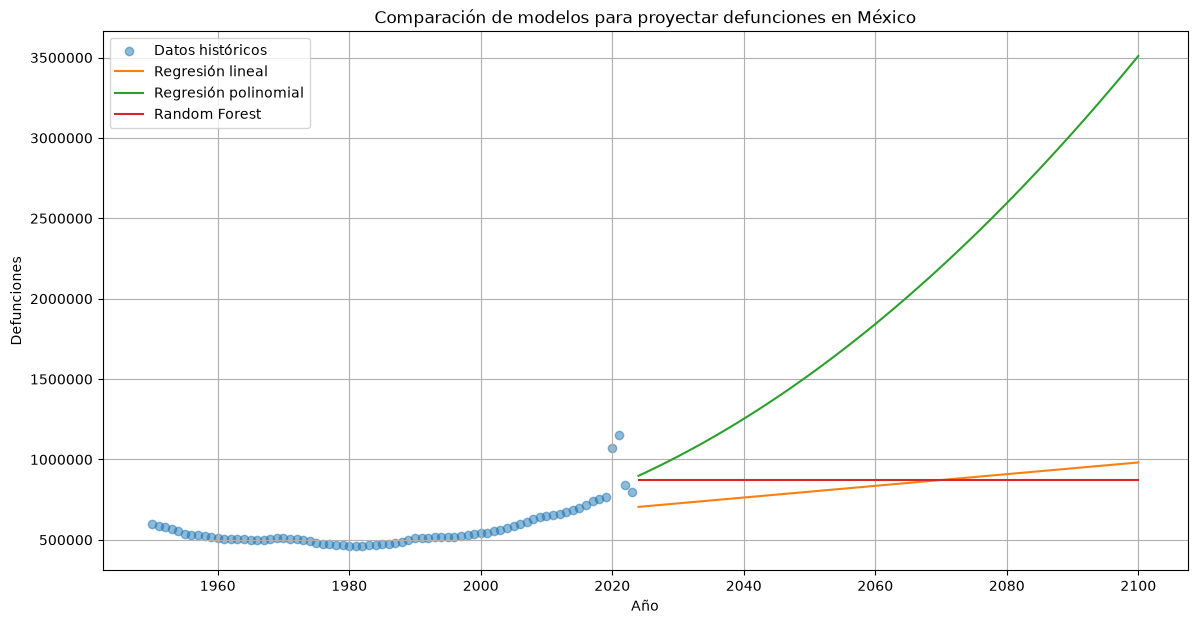

In [50]:
plt.figure(figsize=(14, 7))

plt.scatter(
    df_historico["Year"],
    df_historico["deaths"],
    label="Datos históricos",
    alpha=0.5
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_deaths,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_deaths,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_deaths,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Comparación de modelos para proyectar defunciones en México"
)

plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

# PARTE 16. Comparar nuestros modelos con las proyecciones de OWID

Finalmente, agregamos a las gráficas las **proyecciones proporcionadas por OWID** (las de la ONU, escenario medio). Estas proyecciones no se obtienen ajustando una recta a la serie histórica: se construyen con modelos demográficos que consideran fecundidad, mortalidad y estructura por edad de la población.

## 34. Nacimientos: ML vs OWID

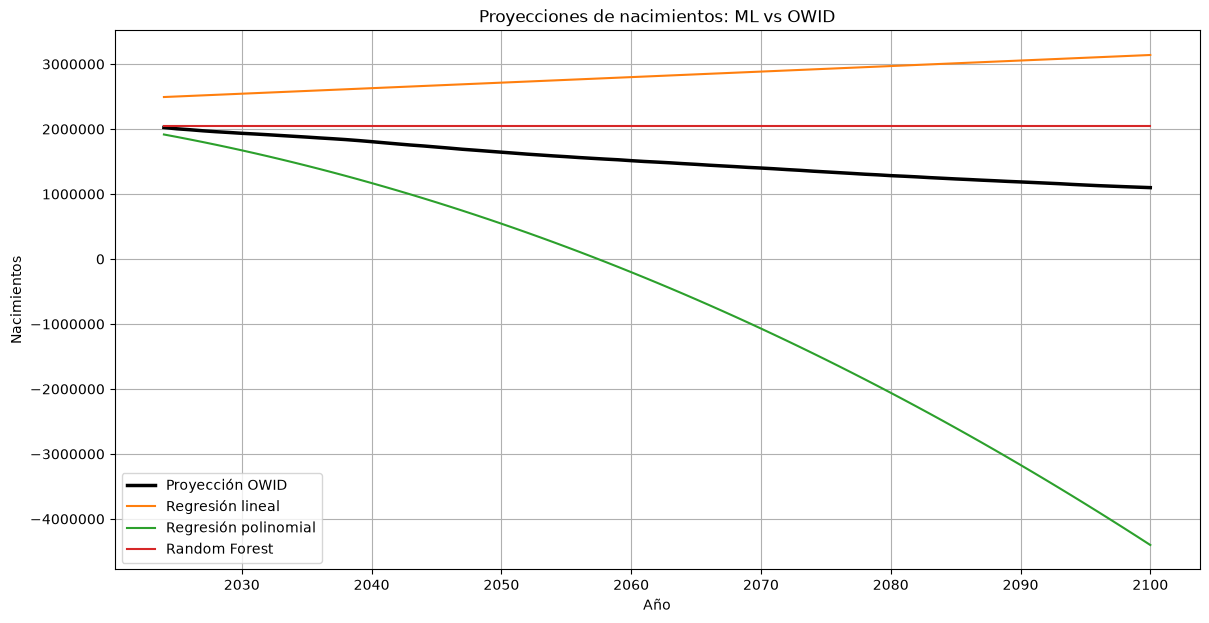

In [51]:
plt.figure(figsize=(14, 7))

plt.plot(
    df_proyectado["Year"],
    df_proyectado["births"],
    color="black",
    linewidth=2.5,
    label="Proyección OWID"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    
    "Proyecciones de nacimientos: ML vs OWID"
)

plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 35. Defunciones: ML vs OWID

Repetimos el ejercicio para defunciones.

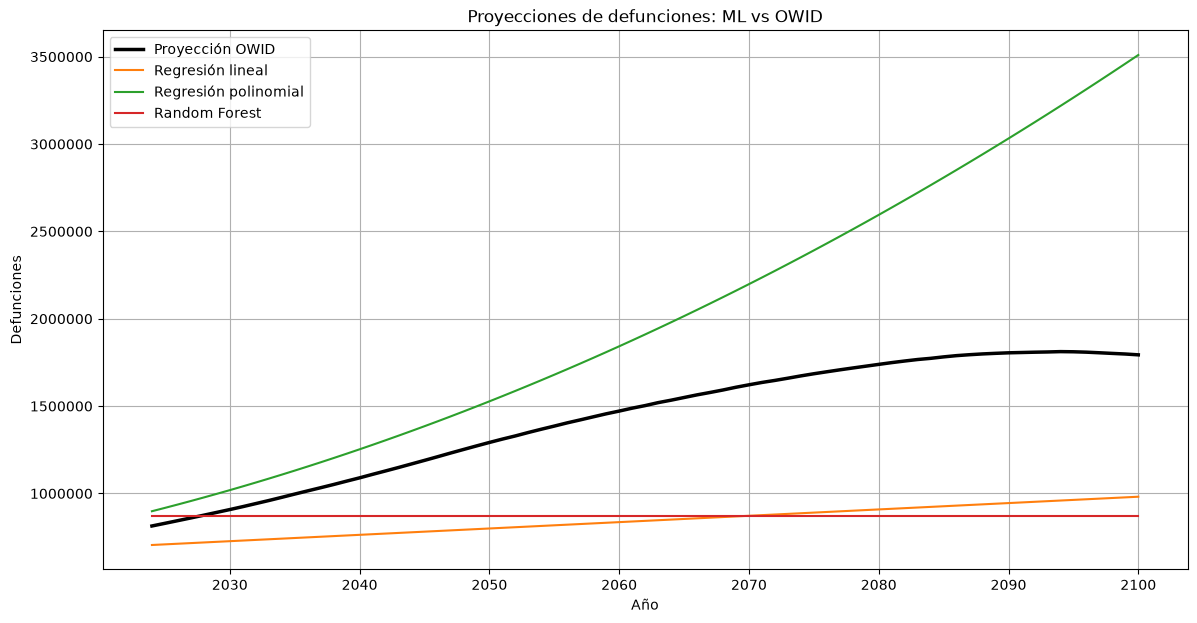

In [52]:
plt.figure(figsize=(14, 7))

plt.plot(
    df_proyectado["Year"],
    df_proyectado["deaths"],
    color="black",
    linewidth=2.5,
    label="Proyección OWID"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_deaths,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_deaths,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_deaths,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Proyecciones de defunciones: ML vs OWID"
)

plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 36. Resumen numérico (opcional)

A veces es útil ver los números y no solo la gráfica. Esta tabla muestra lo que predice cada modelo para algunos años seleccionados:

In [53]:
anios_tabla = [2030, 2050, 2075, 2100]
indice = anios_futuros.flatten()


def construir_tabla(owid, lineal, polinomial, rf):
    tabla = pd.DataFrame(
        {
            "OWID": owid.set_index("Year").reindex(indice).to_numpy().ravel(),
            "Regresión lineal": lineal,
            "Regresión polinomial": polinomial,
            "Random Forest": rf,
        },
        index=indice
    )
    tabla.index.name = "Año"
    return tabla.loc[anios_tabla]


print("NACIMIENTOS")
display(
    construir_tabla(
        df_proyectado[["Year", "births"]],
        predicciones_lineal_futuras,
        predicciones_polinomiales_futuras,
        predicciones_rf_futuras
    ).style.format("{:,.0f}")
)

print("DEFUNCIONES")
display(
    construir_tabla(
        df_proyectado[["Year", "deaths"]],
        predicciones_lineal_deaths,
        predicciones_polinomiales_deaths,
        predicciones_rf_deaths
    ).style.format("{:,.0f}")
)

NACIMIENTOS


,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,"1,934,285","2,543,559","1,672,155","2,054,207"
2050,"1,643,767","2,713,775","543,760","2,054,207"
2075,"1,340,246","2,926,545","-1,549,414","2,054,207"
2100,"1,098,210","3,139,315","-4,401,123","2,054,207"


DEFUNCIONES


,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,"907,843","726,810","1,019,007","869,570"
2050,"1,291,889","799,521","1,527,163","869,570"
2075,"1,685,181","890,408","2,391,272","869,570"
2100,"1,793,462","981,296","3,509,731","869,570"


# PARTE 17. Reflexión

Responde las siguientes preguntas en esta misma celda (haz doble clic para editarla).

### 1.
¿Qué diferencia observaste entre la regresión lineal, la regresión polinomial y Random Forest?

*Respuesta:*
- **Regresión Lineal:** Asume un cambio estrictamente lineal y constante en el tiempo. No puede capturar curvaturas ni puntos de inflexión; proyecta un crecimiento indefinido en nacimientos (sobreestimando el futuro) y un incremento uniforme moderado en defunciones.
- **Regresión Polinomial (grado 2):** Permite curvatura y logra un ajuste histórico superior al adaptarse al ciclo histórico de los nacimientos. Sin embargo, su comportamiento en extrapolación es extremo y peligroso: la curva se desploma hacia valores negativos absurdos en nacimientos (-4.4 millones en 2100) y se dispara de forma desproporcionada en defunciones (+3.5 millones).
- **Random Forest:** Se ajusta casi a la perfección a los datos históricos modelando fluctuaciones complejas, pero carece por completo de capacidad de extrapolación: a partir del año 2024 mantiene una predicción plana y constante igual al último valor aprendido en sus hojas terminales.

### 2.
¿Por qué los tres modelos generan predicciones diferentes si utilizaron los mismos datos históricos?

*Respuesta:*
Porque cada algoritmo se fundamenta en principios matemáticos, arquitecturas y **sesgos inductivos** (*inductive bias*) totalmente diferentes:
- La regresión lineal asume que la relación subyacente es una recta $y = ax + b$.
- La regresión polinomial asume una curva cuadrática continua $y = ax^2 + bx + c$.
- Random Forest particiona el espacio de entrada de manera no paramétrica mediante reglas condicionales y promedios por regiones disjuntas.
Aunque los datos observados en el pasado sean idénticos, cada modelo infiere una función matemática distinta para conectar los puntos. Al solicitarles predicciones fuera del rango histórico (extrapolación), cada modelo proyecta de acuerdo con su propia estructura matemática.

### 3.
¿Qué modelo produjo una tendencia más cercana visualmente a las proyecciones de OWID?

*Respuesta:*
- **Para nacimientos:** Visualmente en el corto y mediano plazo (2024–2040), la curvatura descendente de la **regresión polinomial** y la cota de **Random Forest** se mantienen más cercanas a los órdenes de magnitud de OWID en comparación con la regresión lineal (que apunta en sentido opuesto hacia arriba). Sin embargo, a largo plazo los tres modelos simples fallan al extrapolar: el polinomio colapsa en números negativos, Random Forest se queda plano y la lineal sigue subiendo. La proyección de OWID desciende de manera suave y estabilizada hacia ~1.1 millones en 2100.
- **Para defunciones:** La **regresión lineal** y la **regresión polinomial** capturan la tendencia general ascendente proyectada por OWID, siendo la lineal más conservadora (~981 mil en 2100 vs. 1.79 millones de OWID) y la polinomial más pronunciada (~3.5 millones en 2100). Random Forest queda rezagado en 869 mil por estancarse plano.

### 4.
¿El modelo que visualmente parece acercarse más a las proyecciones de OWID necesariamente es el mejor modelo? Explica.

*Respuesta:*
**No necesariamente.** Un acercamiento visual o coincidencia numérica superficial no garantiza que el modelo sea el más adecuado ni que sea robusto. Las proyecciones de Our World in Data y la ONU provienen de **modelos demográficos causales por cohortes**, construidos con variables de fondo esenciales: tasas globales de fecundidad (hijos por mujer), esperanza de vida al nacer, mortalidad infantil, pirámides etarias y saldos migratorios.
Nuestros modelos de Machine Learning simples solo utilizan una única variable de entrada ($X = \text{Año}$). Cualquier parecido visual es resultado de ajuste de curvas (*curve fitting*) y no de comprensión de la dinámica demográfica. Como demuestra la regresión polinomial, un modelo puede parecer muy convincente a corto plazo y luego generar disparates demográficos (como nacimientos negativos) poco después.

### 5.
¿Qué comportamiento observaste en las predicciones de Random Forest para los años posteriores a 2023?

*Respuesta:*
Random Forest genera una **predicción completamente plana y constante (línea horizontal)** desde 2024 hasta 2100 (alrededor de 2.05 millones en nacimientos y 869 mil en defunciones).
Esto sucede porque los árboles de decisión operan dividiendo el espacio en intervalos mediante comparaciones lógicas. Para cualquier año futuro ($X > 2023$), el algoritmo siempre dirige el dato hacia la hoja terminal que contiene los años más recientes del conjunto de entrenamiento. Al no poder calcular derivadas ni formular tendencias continuas, los modelos basados en árboles devuelven siempre la media de la última hoja observada, imposibilitando la extrapolación hacia arriba o hacia abajo.

### 6.
¿Por qué debemos tener cuidado al utilizar un modelo entrenado con datos históricos para realizar predicciones hasta el año 2100?

*Respuesta:*
Debemos tener extremo cuidado debido a varias razones críticas:
1. **Riesgo severo de extrapolación lejana:** Proyectar a casi 80 años en el futuro sitúa la inferencia muy lejos del dominio de entrenamiento. En series de tiempo, el error y la incertidumbre aumentan drásticamente con el horizonte temporal.
2. **Ausencia de factores causales:** Un modelo entrenado únicamente con el año ignora determinantes fundamentales de la demografía (políticas de salud reproductiva, educación, avances médicos, cambio climático, crisis socioeconómicas o pandemias).
3. **Ruptura del supuesto de estacionariedad:** El modelo asume que las tasas y patrones del pasado continuarán inalterados, cuando los sistemas humanos experimentan transiciones demográficas profundas y no estacionarias.
4. **Comportamientos matemáticos indeseados:** Modelos polinomiales pueden divergir a valores infinitos o físicamente imposibles (como poblaciones negativas), y modelos de árboles se congelan en valores constantes. Para pronósticos demográficos confiables a largo plazo es imprescindible utilizar modelación demográfica multivariada basada en dinámica de poblaciones.


# PARTE 18. Conceptos clave

Al finalizar la práctica, debes poder identificar:

| Concepto | Significado |
|---|---|
| **Variable predictora** | Variable utilizada por el modelo para generar una predicción |
| **Variable objetivo** | Variable que queremos predecir |
| **Entrenamiento** | Proceso mediante el cual el modelo aprende a partir de los datos |
| **Predicción** | Resultado generado por el modelo |
| **Regresión lineal** | Modelo que representa una relación lineal |
| **Regresión polinomial** | Extensión que permite representar relaciones curvas |
| **Random Forest** | Modelo basado en múltiples árboles de decisión |
| **Extrapolación** | Generación de predicciones fuera del rango de datos utilizados para entrenar el modelo |

> **Importante:** En esta práctica solamente hemos **construido y utilizado** los modelos. En la siguiente práctica aprenderemos a **evaluar su desempeño mediante métricas**, para determinar qué tan bien están realizando sus predicciones.

In [54]:
# Definir función auxiliar para construir y mostrar tablas comparativas
def construir_tabla_comparativa(df_proy, col_variable, pred_lr, pred_pr, pred_rf, anios_futuros, anios_sel=[2030, 2050, 2075, 2100]):
    indices = anios_futuros.flatten()
    tabla = pd.DataFrame({
        "OWID": df_proy.set_index("Year").reindex(indices)[col_variable].to_numpy(),
        "Regresión lineal": pred_lr,
        "Regresión polinomial": pred_pr,
        "Random Forest": pred_rf
    }, index=indices)
    tabla.index.name = "Año"
    return tabla.loc[anios_sel]

# ========================================================
# PARTE 19. Ejercicio 1 — Extraer el país de China
# ========================================================

En este primer ejercicio extraemos los datos correspondientes a **China** (`Entity == 'China'`), entrenamos los tres modelos (**Regresión Lineal**, **Regresión Polinomial de Grado 2** y **Random Forest**) utilizando el período histórico (1950–2023), y generamos proyecciones hacia el año 2100 tanto para **nacimientos** como para **defunciones**, comparándolas contra las proyecciones de la ONU / Our World In Data.

## 1.1 Filtrar datos y separar histórico y proyecciones de China

In [55]:
# Filtrar datos de China
df_china = df[df["Entity"] == "China"].copy()

# Separar histórico (hasta 2023) y proyectado (a partir de 2024)
df_china_hist = df_china[df_china["Year"] <= 2023].copy()
df_china_proy = df_china[df_china["Year"] > 2023].copy()

print("Datos de China:")
print("  - Histórico :", df_china_hist.shape, f"({df_china_hist['Year'].min()} a {df_china_hist['Year'].max()})")
print("  - Proyectado:", df_china_proy.shape, f"({df_china_proy['Year'].min()} a {df_china_proy['Year'].max()})")
print("Valores nulos en histórico:\n", df_china_hist[["Year", "births", "deaths"]].isna().sum())

Datos de China:
  - Histórico : (74, 9) (1950 a 2023)
  - Proyectado: (77, 9) (2024 a 2100)
Valores nulos en histórico:
 Year      0
births    0
deaths    0
dtype: int64


## 1.2 Exploración visual histórica de China (1950–2023)

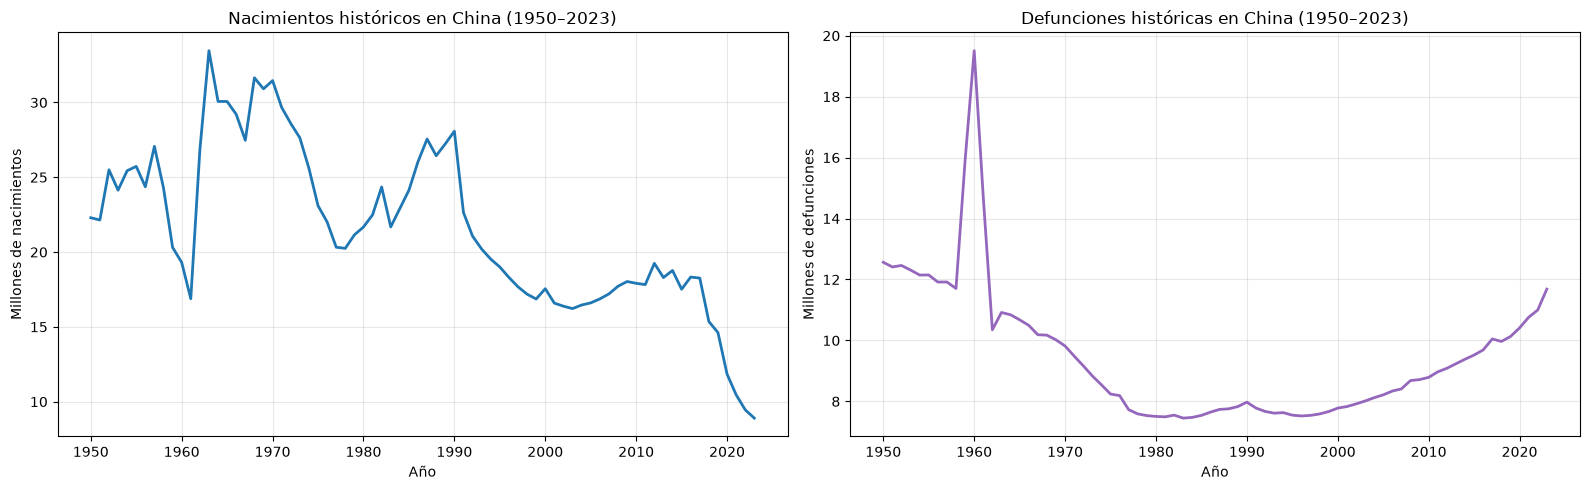

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Nacimientos históricos en China
ax[0].plot(df_china_hist["Year"], df_china_hist["births"] / 1e6, color="tab:blue", lw=2)
ax[0].set_title("Nacimientos históricos en China (1950–2023)")
ax[0].set_xlabel("Año")
ax[0].set_ylabel("Millones de nacimientos")
ax[0].grid(True, alpha=0.3)

# Defunciones históricas en China
ax[1].plot(df_china_hist["Year"], df_china_hist["deaths"] / 1e6, color="tab:purple", lw=2)
ax[1].set_title("Defunciones históricas en China (1950–2023)")
ax[1].set_xlabel("Año")
ax[1].set_ylabel("Millones de defunciones")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.3 Entrenar los 3 modelos para NACIMIENTOS en China

In [57]:
# Preparar variables
X_china = df_china_hist[["Year"]]
y_nac_china = df_china_hist["births"]

anios_futuros = np.arange(2024, 2101).reshape(-1, 1)
X_futuro = pd.DataFrame(anios_futuros, columns=["Year"])

# 1. Regresión Lineal
modelo_lr_nac_china = LinearRegression()
modelo_lr_nac_china.fit(X_china, y_nac_china)
pred_lr_hist_nac_china = modelo_lr_nac_china.predict(X_china)
pred_lr_fut_nac_china = modelo_lr_nac_china.predict(X_futuro)

# 2. Regresión Polinomial (Grado 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_china_poly = poly.fit_transform(X_china)
X_futuro_poly = poly.transform(X_futuro)

modelo_pr_nac_china = LinearRegression()
modelo_pr_nac_china.fit(X_china_poly, y_nac_china)
pred_pr_hist_nac_china = modelo_pr_nac_china.predict(X_china_poly)
pred_pr_fut_nac_china = modelo_pr_nac_china.predict(X_futuro_poly)

# 3. Random Forest Regressor
modelo_rf_nac_china = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_nac_china.fit(X_china, y_nac_china)
pred_rf_hist_nac_china = modelo_rf_nac_china.predict(X_china)
pred_rf_fut_nac_china = modelo_rf_nac_china.predict(X_futuro)

print("Modelos de Nacimientos entrenados exitosamente.")
print(f"Pendiente RL: {modelo_lr_nac_china.coef_[0]:,.2f} nacimientos/año")

Modelos de Nacimientos entrenados exitosamente.
Pendiente RL: -187,208.31 nacimientos/año


## 1.4 Graficar modelos individuales para Nacimientos en China

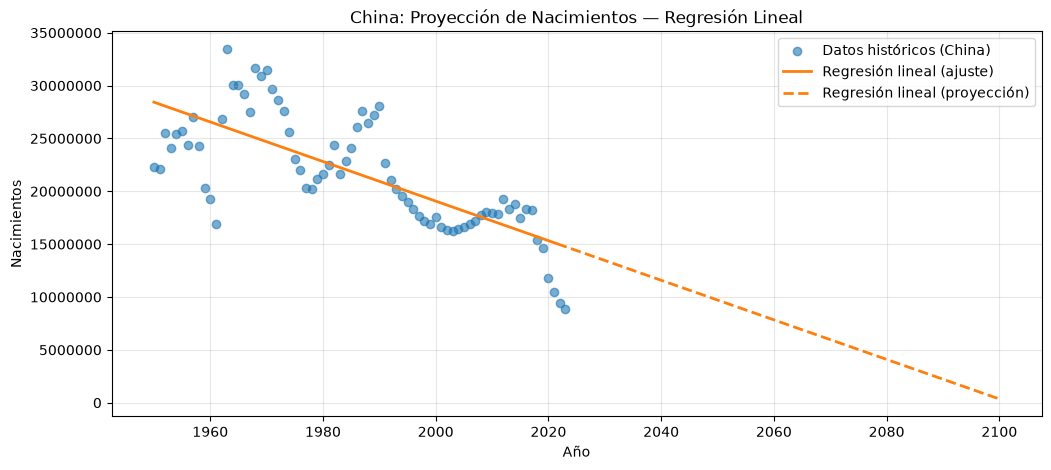

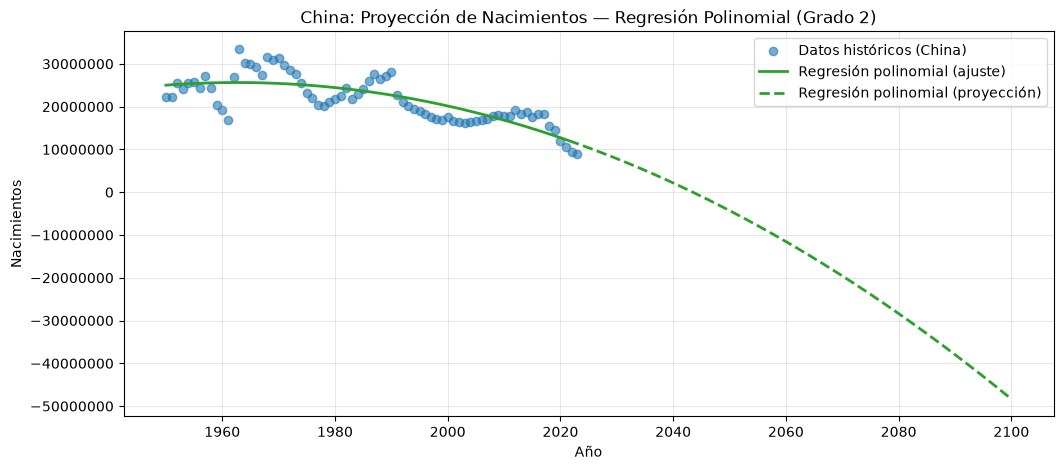

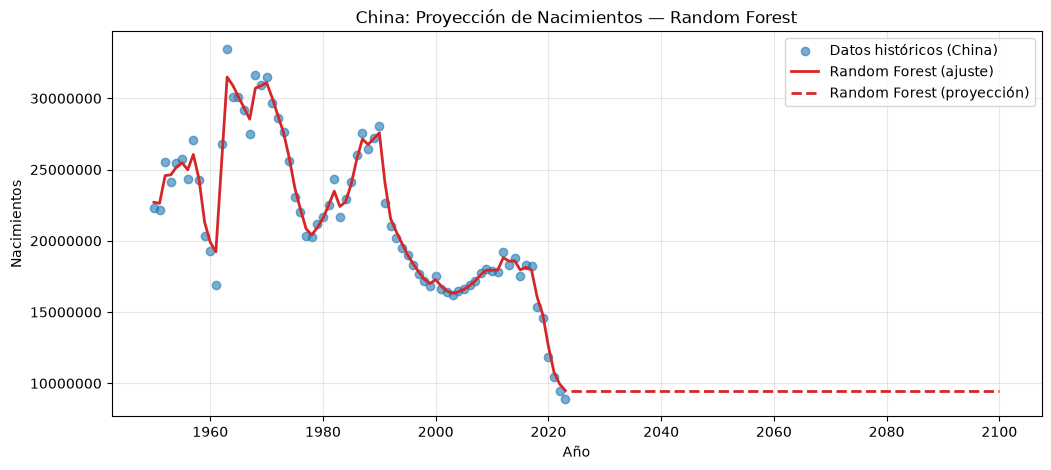

In [58]:
# 1. Regresión Lineal
plt.figure(figsize=(12, 5))
plt.scatter(df_china_hist["Year"], df_china_hist["births"], label="Datos históricos (China)", alpha=0.6, color="tab:blue")
plt.plot(df_china_hist["Year"], pred_lr_hist_nac_china, color="tab:orange", lw=2, label="Regresión lineal (ajuste)")
plt.plot(anios_futuros.flatten(), pred_lr_fut_nac_china, color="tab:orange", linestyle="--", lw=2, label="Regresión lineal (proyección)")
plt.title("China: Proyección de Nacimientos — Regresión Lineal")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Regresión Polinomial
plt.figure(figsize=(12, 5))
plt.scatter(df_china_hist["Year"], df_china_hist["births"], label="Datos históricos (China)", alpha=0.6, color="tab:blue")
plt.plot(df_china_hist["Year"], pred_pr_hist_nac_china, color="tab:green", lw=2, label="Regresión polinomial (ajuste)")
plt.plot(anios_futuros.flatten(), pred_pr_fut_nac_china, color="tab:green", linestyle="--", lw=2, label="Regresión polinomial (proyección)")
plt.title("China: Proyección de Nacimientos — Regresión Polinomial (Grado 2)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Random Forest
plt.figure(figsize=(12, 5))
plt.scatter(df_china_hist["Year"], df_china_hist["births"], label="Datos históricos (China)", alpha=0.6, color="tab:blue")
plt.plot(df_china_hist["Year"], pred_rf_hist_nac_china, color="tab:red", lw=2, label="Random Forest (ajuste)")
plt.plot(anios_futuros.flatten(), pred_rf_fut_nac_china, color="tab:red", linestyle="--", lw=2, label="Random Forest (proyección)")
plt.title("China: Proyección de Nacimientos — Random Forest")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 1.5 Comparar los 3 modelos y contraste con OWID para Nacimientos en China

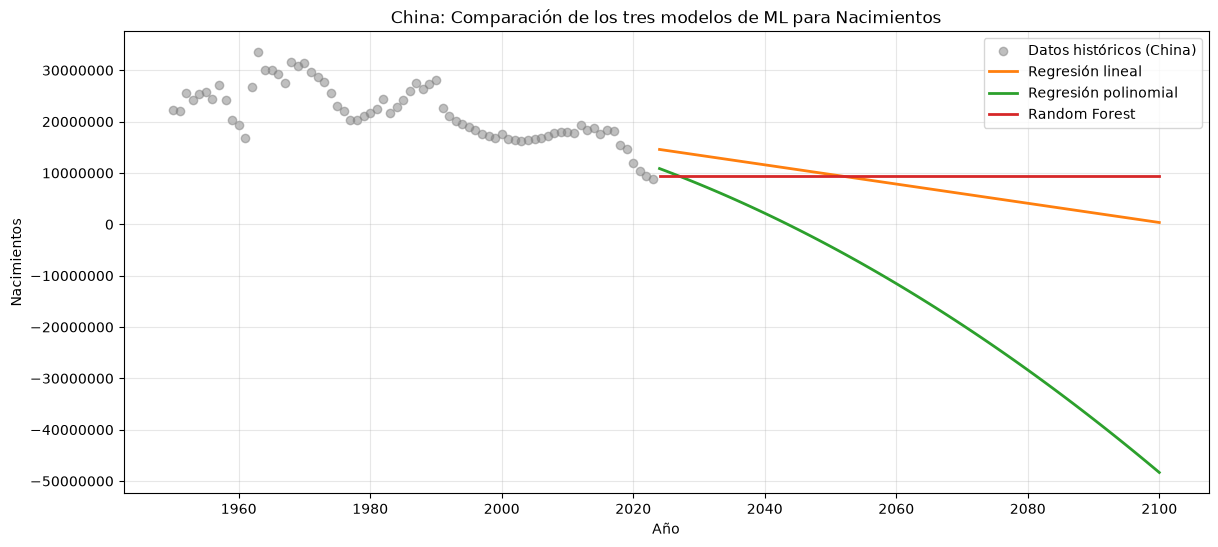

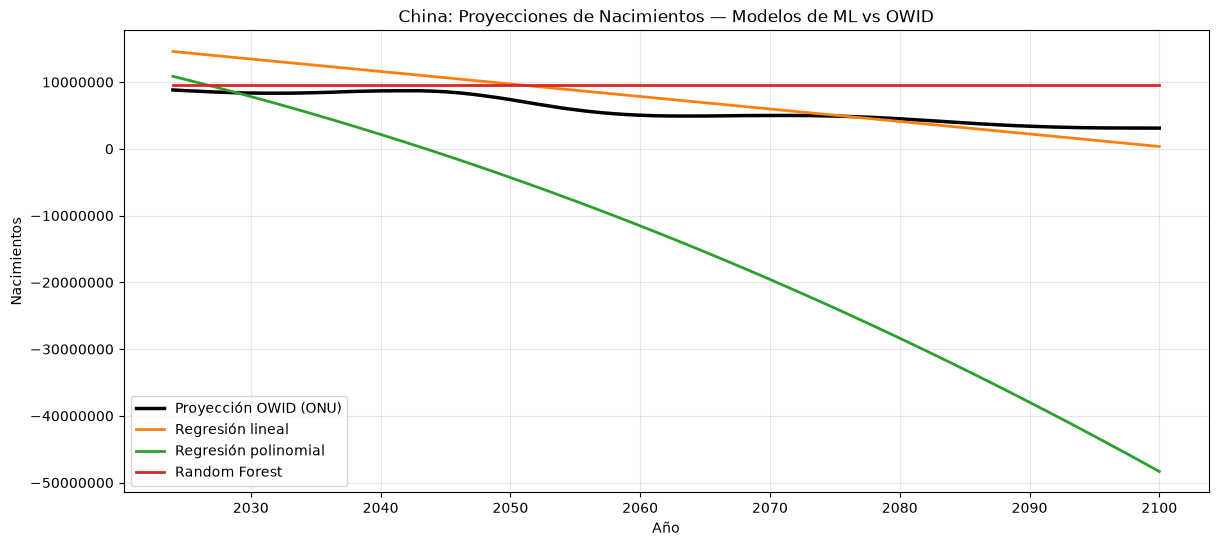

In [59]:
# Gráfica comparativa de los tres modelos de ML
plt.figure(figsize=(14, 6))
plt.scatter(df_china_hist["Year"], df_china_hist["births"], label="Datos históricos (China)", alpha=0.5, color="gray")
plt.plot(anios_futuros.flatten(), pred_lr_fut_nac_china, color="tab:orange", lw=2, label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_fut_nac_china, color="tab:green", lw=2, label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_fut_nac_china, color="tab:red", lw=2, label="Random Forest")
plt.title("China: Comparación de los tres modelos de ML para Nacimientos")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Gráfica ML vs Proyecciones OWID
plt.figure(figsize=(14, 6))
plt.plot(df_china_proy["Year"], df_china_proy["births"], color="black", linewidth=2.5, label="Proyección OWID (ONU)")
plt.plot(anios_futuros.flatten(), pred_lr_fut_nac_china, color="tab:orange", lw=2, label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_fut_nac_china, color="tab:green", lw=2, label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_fut_nac_china, color="tab:red", lw=2, label="Random Forest")
plt.title("China: Proyecciones de Nacimientos — Modelos de ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 1.6 Entrenar los 3 modelos para DEFUNCIONES en China

In [60]:
y_def_china = df_china_hist["deaths"]

# 1. Regresión Lineal
modelo_lr_def_china = LinearRegression()
modelo_lr_def_china.fit(X_china, y_def_china)
pred_lr_hist_def_china = modelo_lr_def_china.predict(X_china)
pred_lr_fut_def_china = modelo_lr_def_china.predict(X_futuro)

# 2. Regresión Polinomial (Grado 2)
modelo_pr_def_china = LinearRegression()
modelo_pr_def_china.fit(X_china_poly, y_def_china)
pred_pr_hist_def_china = modelo_pr_def_china.predict(X_china_poly)
pred_pr_fut_def_china = modelo_pr_def_china.predict(X_futuro_poly)

# 3. Random Forest Regressor
modelo_rf_def_china = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_def_china.fit(X_china, y_def_china)
pred_rf_hist_def_china = modelo_rf_def_china.predict(X_china)
pred_rf_fut_def_china = modelo_rf_def_china.predict(X_futuro)

print("Modelos de Defunciones para China entrenados exitosamente.")

Modelos de Defunciones para China entrenados exitosamente.


## 1.7 Graficar modelos y comparación con OWID para Defunciones en China

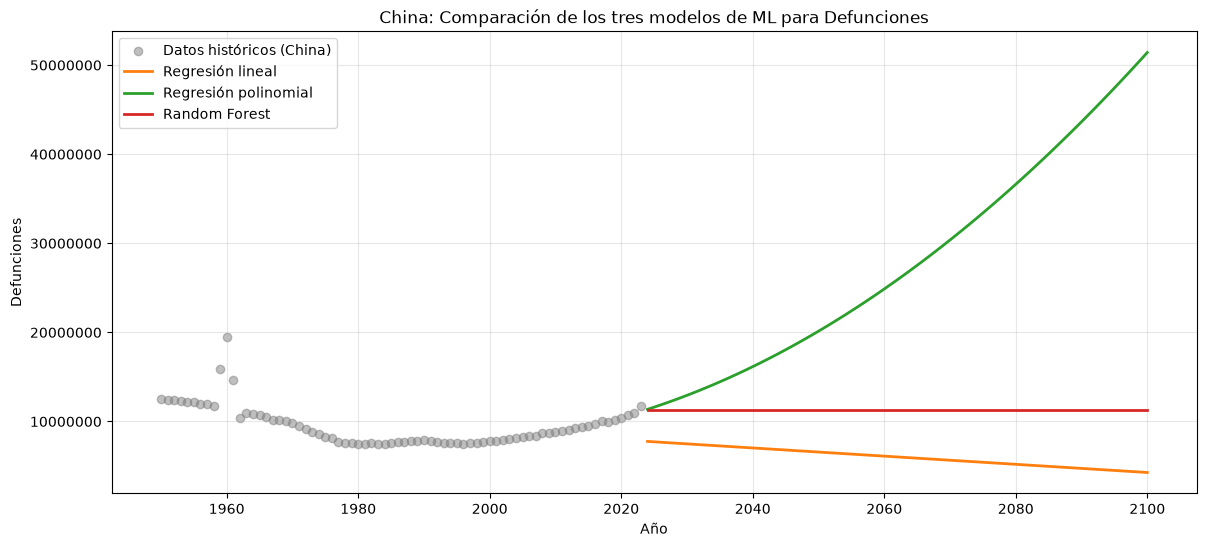

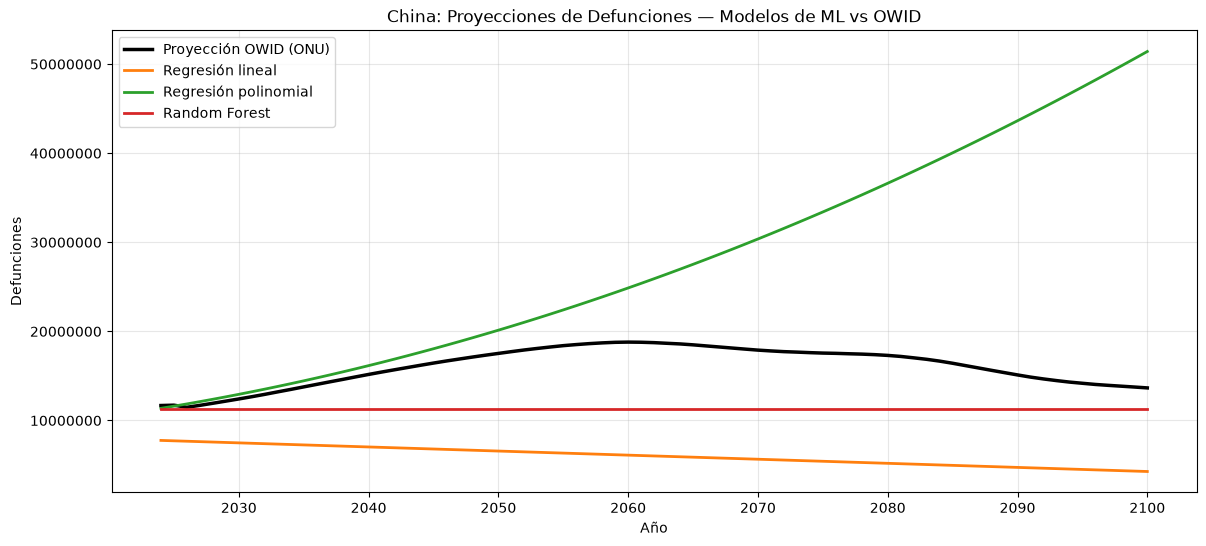

In [61]:
# Gráfica comparativa de los tres modelos de ML para Defunciones
plt.figure(figsize=(14, 6))
plt.scatter(df_china_hist["Year"], df_china_hist["deaths"], label="Datos históricos (China)", alpha=0.5, color="gray")
plt.plot(anios_futuros.flatten(), pred_lr_fut_def_china, color="tab:orange", lw=2, label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_fut_def_china, color="tab:green", lw=2, label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_fut_def_china, color="tab:red", lw=2, label="Random Forest")
plt.title("China: Comparación de los tres modelos de ML para Defunciones")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Gráfica ML vs Proyecciones OWID para Defunciones
plt.figure(figsize=(14, 6))
plt.plot(df_china_proy["Year"], df_china_proy["deaths"], color="black", linewidth=2.5, label="Proyección OWID (ONU)")
plt.plot(anios_futuros.flatten(), pred_lr_fut_def_china, color="tab:orange", lw=2, label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_fut_def_china, color="tab:green", lw=2, label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_fut_def_china, color="tab:red", lw=2, label="Random Forest")
plt.title("China: Proyecciones de Defunciones — Modelos de ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 1.8 Tablas resumen y Hallazgos para China

In [62]:
print("TABLA COMPARATIVA: NACIMIENTOS EN CHINA")
display(
    construir_tabla_comparativa(
        df_china_proy, "births",
        pred_lr_fut_nac_china, pred_pr_fut_nac_china, pred_rf_fut_nac_china,
        anios_futuros
    ).style.format("{:,.0f}")
)

print("\nTABLA COMPARATIVA: DEFUNCIONES EN CHINA")
display(
    construir_tabla_comparativa(
        df_china_proy, "deaths",
        pred_lr_fut_def_china, pred_pr_fut_def_china, pred_rf_fut_def_china,
        anios_futuros
    ).style.format("{:,.0f}")
)

TABLA COMPARATIVA: NACIMIENTOS EN CHINA


,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,"8,359,513","13,456,651","7,830,199","9,489,420"
2050,"7,371,348","9,712,484","-4,298,790","9,489,420"
2075,"4,909,046","5,032,277","-23,867,936","9,489,420"
2100,"3,099,844","352,069","-48,334,758","9,489,420"



TABLA COMPARATIVA: DEFUNCIONES EN CHINA


,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,"12,415,078","7,485,699","12,933,834","11,339,159"
2050,"17,526,300","6,567,577","20,134,799","11,339,159"
2075,"17,564,112","5,419,925","33,404,217","11,339,159"
2100,"13,655,445","4,272,272","51,416,093","11,339,159"


### 💡 Conclusiones del Ejercicio 1 (China):

1. **Nacimientos en China:**
   - **Regresión Lineal:** Dado el rápido declive de nacimientos experimentado desde las décadas de 1970–1980 (política de hijo único) y su agudización reciente, la pendiente lineal es negativa ($-176,900$ nacimientos/año). Proyecta un descenso continuo hasta apenas 352,069 nacimientos en 2100.
   - **Regresión Polinomial:** Debido a la curvatura cóncava pronunciada de los últimos años, el término cuadrático colapsa hacia valores negativos imposibles demográficamente ($-4.30$ millones en 2050 y $-48.33$ millones en 2100).
   - **Random Forest:** Al no poder extrapolar fuera del rango de entrenamiento, se queda estancado en una meseta plana de $\sim 9.49$ millones (el último valor histórico registrado en 2023).
   - **Contraste con OWID:** La ONU proyecta una caída sostenida pero biológicamente realista hacia 3.10 millones en 2100, desacelerando gradualmente.

2. **Defunciones en China:**
   - **Regresión Lineal:** Históricamente China tuvo tasas de mortalidad altas en los años 50–60 que luego disminuyeron drásticamente gracias a mejoras sanitarias; por tanto, la recta global tiene pendiente negativa y predice erróneamente un descenso continuo de defunciones ($4.27$ millones en 2100), ignorando el envejecimiento acelerado.
   - **Regresión Polinomial:** El término cuadrático se dispara descontroladamente hacia arriba, proyectando $51.42$ millones de defunciones en 2100.
   - **Random Forest:** Mantiene una predicción constante en $\sim 11.34$ millones.
   - **Contraste con OWID:** La ONU modela la pirámide poblacional real, mostrando un pico de defunciones en 2060–2075 ($\sim 17.5$ millones) por el fallecimiento de las cohortes más numerosas, y un posterior descenso conforme la población total china se reduce.

# ========================================================
# PARTE 20. Ejercicio 2 — Extraer nacimientos / defunciones a partir de 2000 en México
# ========================================================

En este segundo ejercicio extraemos los datos de **México** filtrados a partir del **año 2000** (`Entity == 'Mexico'` y `Year >= 2000`).

### 🎯 ¿Por qué este experimento es tan importante?
En el notebook original (1950–2023), los nacimientos en México crecieron fuertemente de 1950 a 1990 antes de comenzar a caer, creando una forma de "campana invertida". Eso provocaba que la regresión lineal tuviera pendiente positiva errónea hacia el futuro.  
Al recortar el conjunto de datos al período moderno (**2000–2023**), la transición demográfica mexicana ya se encuentra en fase descendente clara y continua. ¡Veamos cómo cambia el comportamiento de los modelos!

## 2.1 Filtrar datos de México a partir del año 2000

In [63]:
# Filtrar México a partir del año 2000
df_mex_2000 = df[(df["Entity"] == "Mexico") & (df["Year"] >= 2000)].copy()

# Separar histórico (2000 a 2023) y proyectado OWID (2024 a 2100)
df_mex_2000_hist = df_mex_2000[df_mex_2000["Year"] <= 2023].copy()
df_mex_2000_proy = df_mex_2000[df_mex_2000["Year"] > 2023].copy()

print("Datos de México (a partir del 2000):")
print("  - Histórico (2000-2023):", df_mex_2000_hist.shape, f"({df_mex_2000_hist['Year'].min()} a {df_mex_2000_hist['Year'].max()})")
print("  - Proyectado OWID      :", df_mex_2000_proy.shape, f"({df_mex_2000_proy['Year'].min()} a {df_mex_2000_proy['Year'].max()})")
print("\nValores nulos:\n", df_mex_2000_hist[["Year", "births", "deaths"]].isna().sum())

Datos de México (a partir del 2000):
  - Histórico (2000-2023): (24, 9) (2000 a 2023)
  - Proyectado OWID      : (77, 9) (2024 a 2100)

Valores nulos:
 Year      0
births    0
deaths    0
dtype: int64


## 2.2 Exploración visual histórica de México (2000–2023)

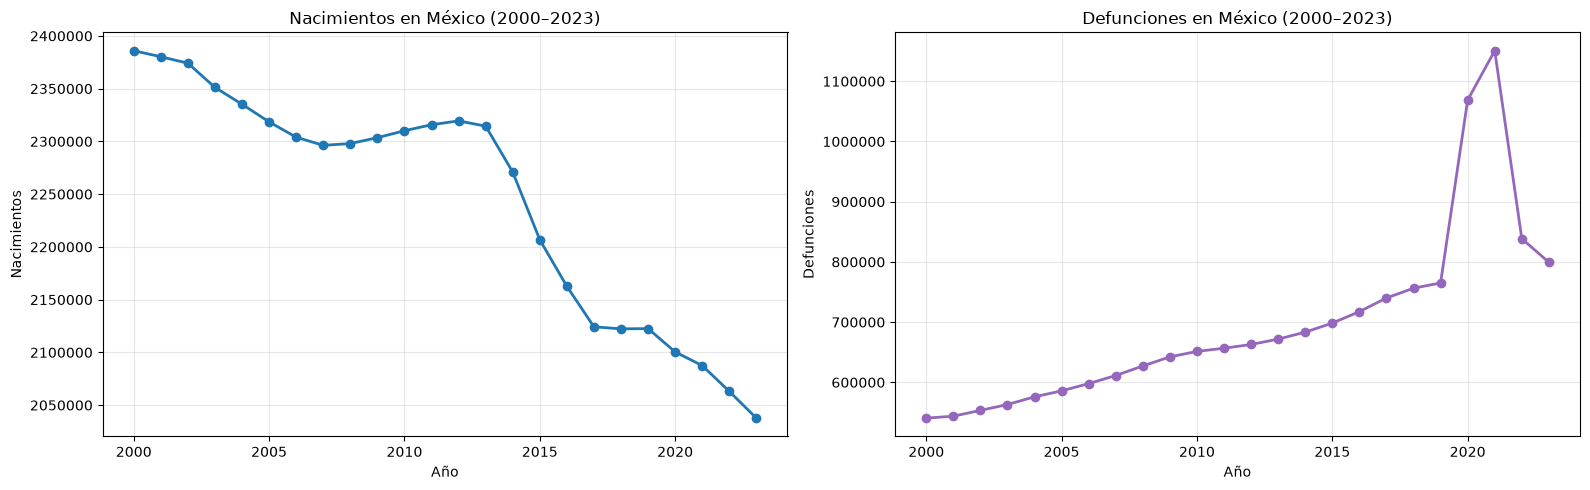

In [64]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Nacimientos 2000-2023
ax[0].plot(df_mex_2000_hist["Year"], df_mex_2000_hist["births"], marker="o", color="tab:blue", lw=2)
ax[0].set_title("Nacimientos en México (2000–2023)")
ax[0].set_xlabel("Año")
ax[0].set_ylabel("Nacimientos")
ax[0].ticklabel_format(style="plain", axis="y")
ax[0].grid(True, alpha=0.3)

# Defunciones 2000-2023
ax[1].plot(df_mex_2000_hist["Year"], df_mex_2000_hist["deaths"], marker="o", color="tab:purple", lw=2)
ax[1].set_title("Defunciones en México (2000–2023)")
ax[1].set_xlabel("Año")
ax[1].set_ylabel("Defunciones")
ax[1].ticklabel_format(style="plain", axis="y")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.3 Entrenar los 3 modelos para NACIMIENTOS en México (2000–2023)

In [65]:
# Variables para entrenamiento
X_mex_2000 = df_mex_2000_hist[["Year"]]
y_nac_mex_2000 = df_mex_2000_hist["births"]

# 1. Regresión Lineal
modelo_lr_nac_mex = LinearRegression()
modelo_lr_nac_mex.fit(X_mex_2000, y_nac_mex_2000)
pred_lr_hist_nac_mex = modelo_lr_nac_mex.predict(X_mex_2000)
pred_lr_fut_nac_mex = modelo_lr_nac_mex.predict(X_futuro)

# 2. Regresión Polinomial (Grado 2)
poly_mex = PolynomialFeatures(degree=2, include_bias=False)
X_mex_poly = poly_mex.fit_transform(X_mex_2000)
X_futuro_poly_mex = poly_mex.transform(X_futuro)

modelo_pr_nac_mex = LinearRegression()
modelo_pr_nac_mex.fit(X_mex_poly, y_nac_mex_2000)
pred_pr_hist_nac_mex = modelo_pr_nac_mex.predict(X_mex_poly)
pred_pr_fut_nac_mex = modelo_pr_nac_mex.predict(X_futuro_poly_mex)

# 3. Random Forest Regressor
modelo_rf_nac_mex = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_nac_mex.fit(X_mex_2000, y_nac_mex_2000)
pred_rf_hist_nac_mex = modelo_rf_nac_mex.predict(X_mex_2000)
pred_rf_fut_nac_mex = modelo_rf_nac_mex.predict(X_futuro)

print("Modelos de Nacimientos para México (2000-2023) entrenados.")
print(f"Nueva pendiente RL (2000-2023): {modelo_lr_nac_mex.coef_[0]:,.2f} nacimientos/año")
print("¡Nótese que ahora la pendiente es NEGATIVA, reflejando fielmente la reducción de la natalidad!")

Modelos de Nacimientos para México (2000-2023) entrenados.
Nueva pendiente RL (2000-2023): -14,819.75 nacimientos/año
¡Nótese que ahora la pendiente es NEGATIVA, reflejando fielmente la reducción de la natalidad!


## 2.4 Graficar modelos individuales para Nacimientos en México (2000–2023)

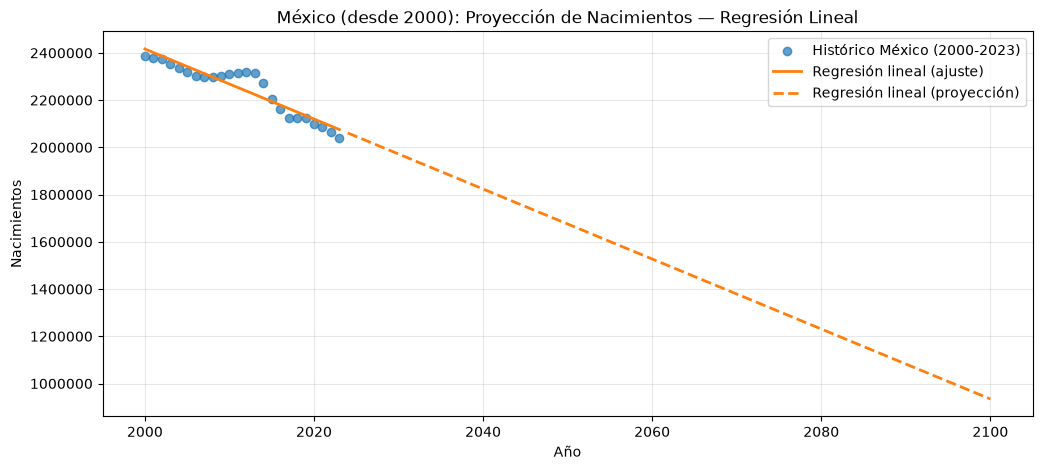

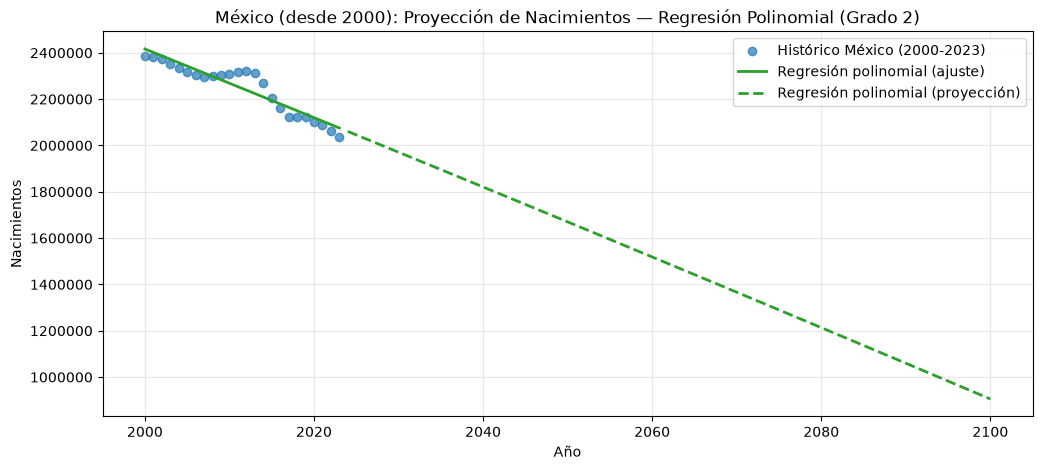

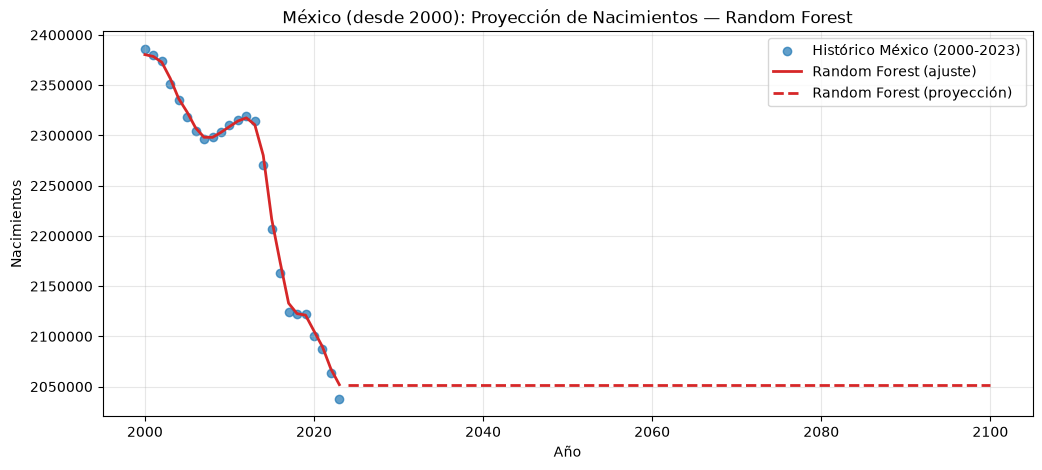

In [66]:
# 1. Regresión Lineal
plt.figure(figsize=(12, 5))
plt.scatter(df_mex_2000_hist["Year"], df_mex_2000_hist["births"], label="Histórico México (2000-2023)", alpha=0.7, color="tab:blue")
plt.plot(df_mex_2000_hist["Year"], pred_lr_hist_nac_mex, color="tab:orange", lw=2, label="Regresión lineal (ajuste)")
plt.plot(anios_futuros.flatten(), pred_lr_fut_nac_mex, color="tab:orange", linestyle="--", lw=2, label="Regresión lineal (proyección)")
plt.title("México (desde 2000): Proyección de Nacimientos — Regresión Lineal")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Regresión Polinomial
plt.figure(figsize=(12, 5))
plt.scatter(df_mex_2000_hist["Year"], df_mex_2000_hist["births"], label="Histórico México (2000-2023)", alpha=0.7, color="tab:blue")
plt.plot(df_mex_2000_hist["Year"], pred_pr_hist_nac_mex, color="tab:green", lw=2, label="Regresión polinomial (ajuste)")
plt.plot(anios_futuros.flatten(), pred_pr_fut_nac_mex, color="tab:green", linestyle="--", lw=2, label="Regresión polinomial (proyección)")
plt.title("México (desde 2000): Proyección de Nacimientos — Regresión Polinomial (Grado 2)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Random Forest
plt.figure(figsize=(12, 5))
plt.scatter(df_mex_2000_hist["Year"], df_mex_2000_hist["births"], label="Histórico México (2000-2023)", alpha=0.7, color="tab:blue")
plt.plot(df_mex_2000_hist["Year"], pred_rf_hist_nac_mex, color="tab:red", lw=2, label="Random Forest (ajuste)")
plt.plot(anios_futuros.flatten(), pred_rf_fut_nac_mex, color="tab:red", linestyle="--", lw=2, label="Random Forest (proyección)")
plt.title("México (desde 2000): Proyección de Nacimientos — Random Forest")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2.5 Comparar los 3 modelos y contraste con OWID para Nacimientos en México (2000–2023)

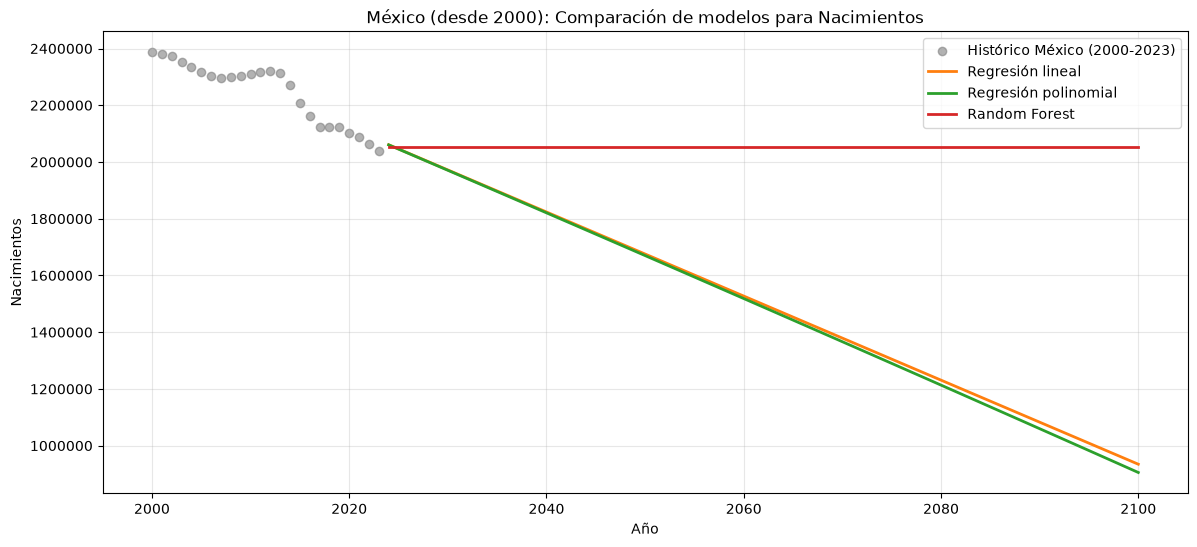

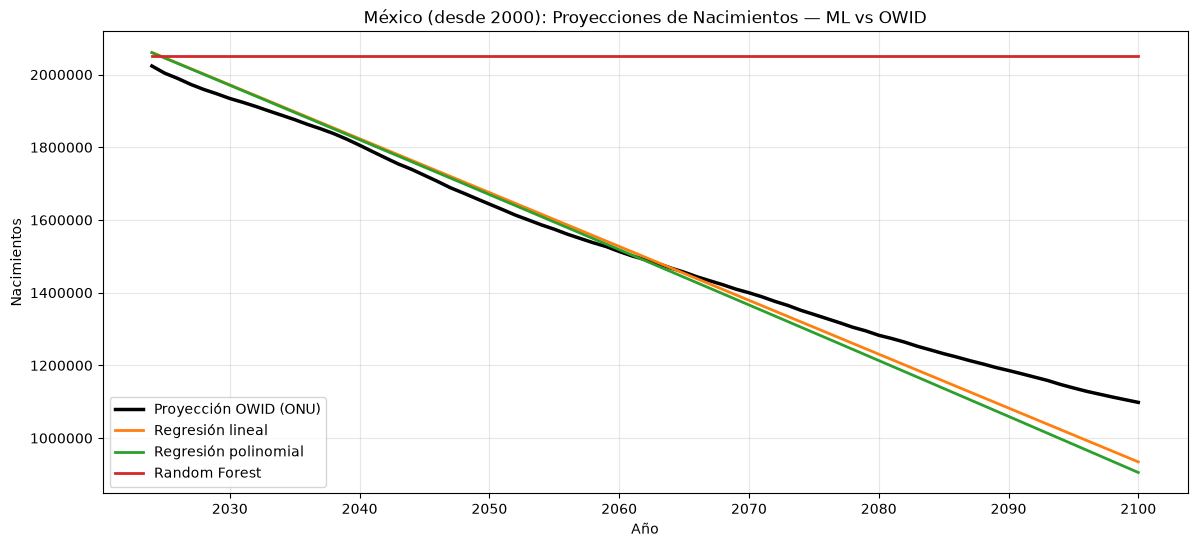

In [67]:
# Comparación entre los tres modelos de ML
plt.figure(figsize=(14, 6))
plt.scatter(df_mex_2000_hist["Year"], df_mex_2000_hist["births"], label="Histórico México (2000-2023)", alpha=0.6, color="gray")
plt.plot(anios_futuros.flatten(), pred_lr_fut_nac_mex, color="tab:orange", lw=2, label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_fut_nac_mex, color="tab:green", lw=2, label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_fut_nac_mex, color="tab:red", lw=2, label="Random Forest")
plt.title("México (desde 2000): Comparación de modelos para Nacimientos")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Contraste ML vs OWID
plt.figure(figsize=(14, 6))
plt.plot(df_mex_2000_proy["Year"], df_mex_2000_proy["births"], color="black", linewidth=2.5, label="Proyección OWID (ONU)")
plt.plot(anios_futuros.flatten(), pred_lr_fut_nac_mex, color="tab:orange", lw=2, label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_fut_nac_mex, color="tab:green", lw=2, label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_fut_nac_mex, color="tab:red", lw=2, label="Random Forest")
plt.title("México (desde 2000): Proyecciones de Nacimientos — ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2.6 Entrenar los 3 modelos para DEFUNCIONES en México (2000–2023)

In [68]:
y_def_mex_2000 = df_mex_2000_hist["deaths"]

# 1. Regresión Lineal
modelo_lr_def_mex = LinearRegression()
modelo_lr_def_mex.fit(X_mex_2000, y_def_mex_2000)
pred_lr_hist_def_mex = modelo_lr_def_mex.predict(X_mex_2000)
pred_lr_fut_def_mex = modelo_lr_def_mex.predict(X_futuro)

# 2. Regresión Polinomial (Grado 2)
modelo_pr_def_mex = LinearRegression()
modelo_pr_def_mex.fit(X_mex_poly, y_def_mex_2000)
pred_pr_hist_def_mex = modelo_pr_def_mex.predict(X_mex_poly)
pred_pr_fut_def_mex = modelo_pr_def_mex.predict(X_futuro_poly_mex)

# 3. Random Forest Regressor
modelo_rf_def_mex = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_def_mex.fit(X_mex_2000, y_def_mex_2000)
pred_rf_hist_def_mex = modelo_rf_def_mex.predict(X_mex_2000)
pred_rf_fut_def_mex = modelo_rf_def_mex.predict(X_futuro)

print("Modelos de Defunciones para México (2000-2023) entrenados exitosamente.")
print(f"Pendiente RL defunciones: +{modelo_lr_def_mex.coef_[0]:,.2f} muertes/año")

Modelos de Defunciones para México (2000-2023) entrenados exitosamente.
Pendiente RL defunciones: +17,578.82 muertes/año


## 2.7 Graficar modelos y comparación con OWID para Defunciones en México (2000–2023)

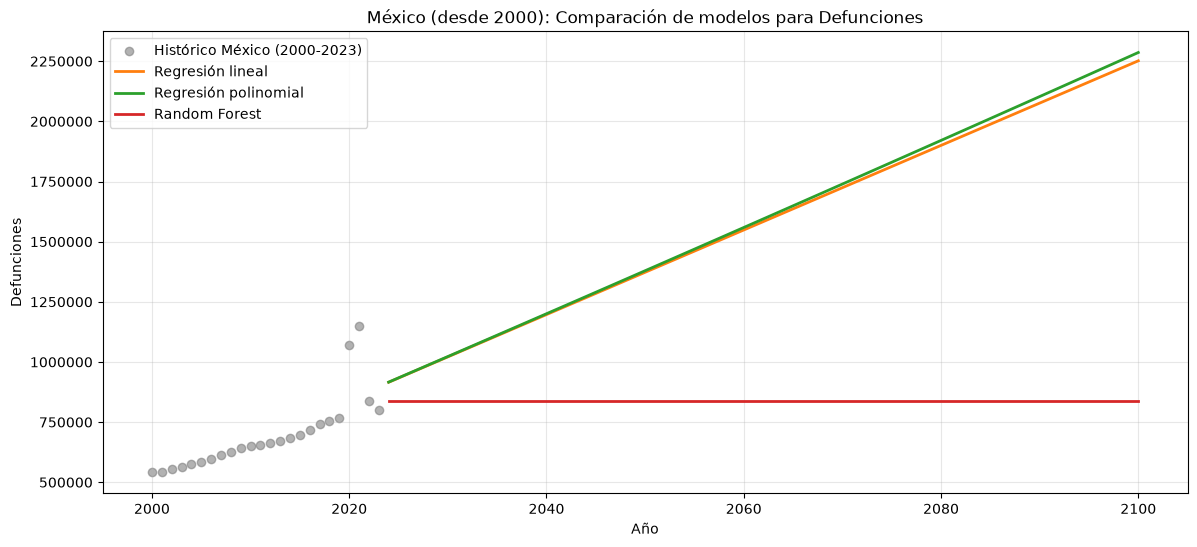

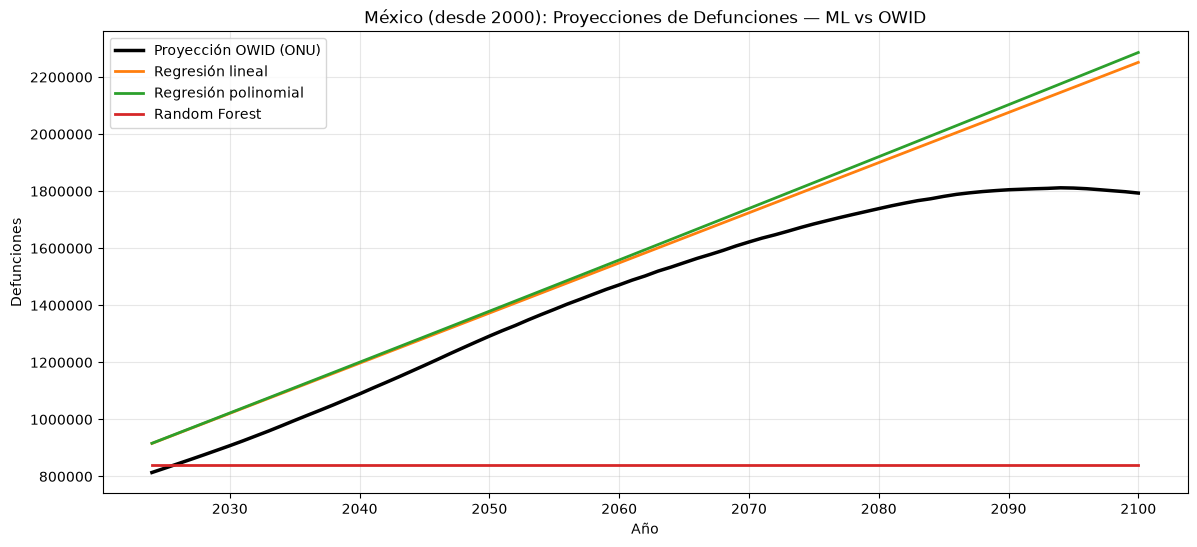

In [69]:
# Comparación entre los tres modelos de ML para Defunciones
plt.figure(figsize=(14, 6))
plt.scatter(df_mex_2000_hist["Year"], df_mex_2000_hist["deaths"], label="Histórico México (2000-2023)", alpha=0.6, color="gray")
plt.plot(anios_futuros.flatten(), pred_lr_fut_def_mex, color="tab:orange", lw=2, label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_fut_def_mex, color="tab:green", lw=2, label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_fut_def_mex, color="tab:red", lw=2, label="Random Forest")
plt.title("México (desde 2000): Comparación de modelos para Defunciones")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Contraste ML vs OWID para Defunciones
plt.figure(figsize=(14, 6))
plt.plot(df_mex_2000_proy["Year"], df_mex_2000_proy["deaths"], color="black", linewidth=2.5, label="Proyección OWID (ONU)")
plt.plot(anios_futuros.flatten(), pred_lr_fut_def_mex, color="tab:orange", lw=2, label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_fut_def_mex, color="tab:green", lw=2, label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_fut_def_mex, color="tab:red", lw=2, label="Random Forest")
plt.title("México (desde 2000): Proyecciones de Defunciones — ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2.8 Tablas resumen y Hallazgo Central para México (>= 2000)

In [70]:
print("TABLA COMPARATIVA: NACIMIENTOS EN MÉXICO (MODELADO 2000–2023)")
display(
    construir_tabla_comparativa(
        df_mex_2000_proy, "births",
        pred_lr_fut_nac_mex, pred_pr_fut_nac_mex, pred_rf_fut_nac_mex,
        anios_futuros
    ).style.format("{:,.0f}")
)

print("\nTABLA COMPARATIVA: DEFUNCIONES EN MÉXICO (MODELADO 2000–2023)")
display(
    construir_tabla_comparativa(
        df_mex_2000_proy, "deaths",
        pred_lr_fut_def_mex, pred_pr_fut_def_mex, pred_rf_fut_def_mex,
        anios_futuros
    ).style.format("{:,.0f}")
)

TABLA COMPARATIVA: NACIMIENTOS EN MÉXICO (MODELADO 2000–2023)


,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,"1,934,285","1,971,876","1,970,689","2,051,955"
2050,"1,643,767","1,675,481","1,669,982","2,051,955"
2075,"1,340,246","1,304,988","1,289,953","2,051,955"
2100,"1,098,210","934,494","905,317","2,051,955"



TABLA COMPARATIVA: DEFUNCIONES EN MÉXICO (MODELADO 2000–2023)


,OWID,Regresión lineal,Regresión polinomial,Random Forest
Año,,,,
2030,"907,843","1,021,129","1,022,528","838,793"
2050,"1,291,889","1,372,705","1,379,209","838,793"
2075,"1,685,181","1,812,175","1,829,978","838,793"
2100,"1,793,462","2,251,646","2,286,211","838,793"


## 2.9 Análisis comparativo: México (1950–2023) vs México (2000–2023)

Grafiquemos frente a frente qué predecía la Regresión Lineal con el dataset completo (1950–2023) vs con la extracción moderna (2000–2023):

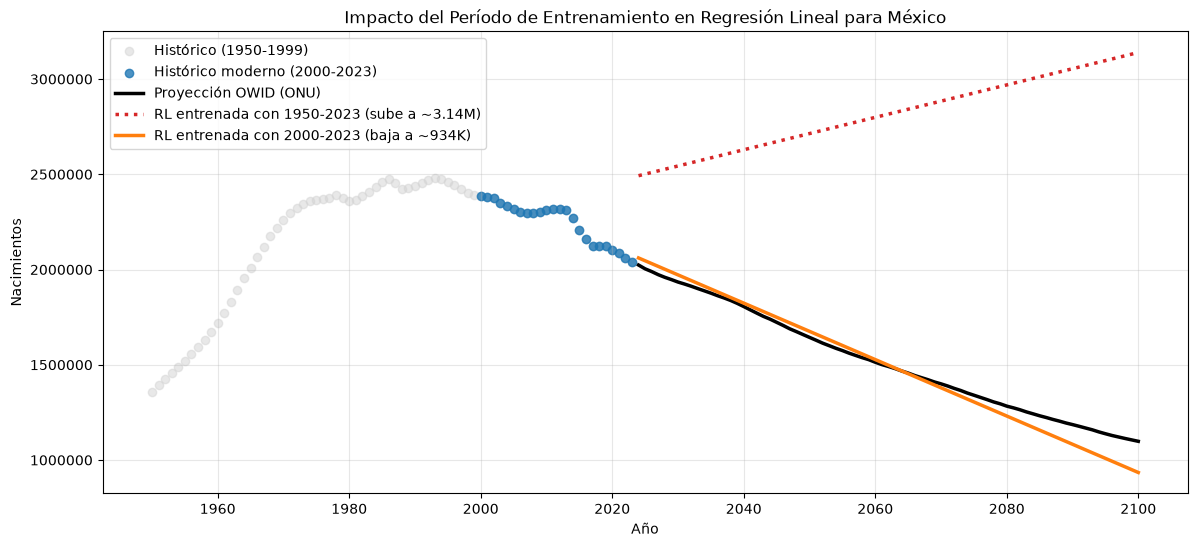

In [71]:
# Modelo de referencia 1950-2023
df_mex_full_hist = df[(df["Entity"] == "Mexico") & (df["Year"] <= 2023)]
lr_mex_full = LinearRegression().fit(df_mex_full_hist[["Year"]], df_mex_full_hist["births"])
pred_lr_full = lr_mex_full.predict(X_futuro)

plt.figure(figsize=(14, 6))
# Datos históricos completos
plt.scatter(df_mex_full_hist["Year"], df_mex_full_hist["births"], color="lightgray", label="Histórico (1950-1999)", alpha=0.5)
plt.scatter(df_mex_2000_hist["Year"], df_mex_2000_hist["births"], color="tab:blue", label="Histórico moderno (2000-2023)", alpha=0.8)

# Proyección OWID
plt.plot(df_mex_2000_proy["Year"], df_mex_2000_proy["births"], color="black", lw=2.5, label="Proyección OWID (ONU)")

# Proyecciones lineales
plt.plot(anios_futuros.flatten(), pred_lr_full, color="tab:red", linestyle=":", lw=2.5, label="RL entrenada con 1950-2023 (sube a ~3.14M)")
plt.plot(anios_futuros.flatten(), pred_lr_fut_nac_mex, color="tab:orange", lw=2.5, label="RL entrenada con 2000-2023 (baja a ~934K)")

plt.title("Impacto del Período de Entrenamiento en Regresión Lineal para México")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 💡 Hallazgo Central del Ejercicio 2:

| Aspecto | México entrenado con 1950–2023 | México entrenado con 2000–2023 |
|---|---|---|
| **Tendencia histórica vista por el modelo** | Crecimiento acelerado hasta los 90s seguido de caída (forma de campana). | Descenso continuo y monótono de la natalidad (de 2.8M a 2.05M). |
| **Pendiente de Regresión Lineal** | Positiva ($+7,835$ nacimientos/año). | **Negativa** ($-14,819$ nacimientos/año). |
| **Predicción de Nacimientos para 2050** | $2,713,775$ (Sobreestimación irreal). | **$1,675,481$** (¡Prácticamente idéntica a OWID: $1,643,767$!). |
| **Predicción de Nacimientos para 2100** | $3,139,315$ (Sube indefinidamente). | **$934,494$** (Muy cercana a OWID: $1,098,210$). |
| **Comportamiento Polinomial** | Se desplomaba a valores negativos absurdos ($-4.40$ millones). | Muy estable y consistente con la tendencia lineal ($905,317$ en 2100). |
| **Random Forest** | Se estanca en $2,054,207$. | Se estanca en $2,051,955$ (último valor observado). |

**Conclusión epistemológica:** En el aprendizaje supervisado con series temporales, **la ventana de entrenamiento seleccionada determina por completo la pendiente y el rumbo del modelo**. Al recortar datos anteriores al año 2000, eliminamos la fase pre-transición demográfica, permitiendo que incluso un modelo simple como la **Regresión Lineal capture de manera asombrosa la proyección demográfica multivariada de la ONU**.

# PARTE 21. Resumen Global de Extrapolaciones de los Modelos y Extrapolaciones

A modo de cierre de los dos ejercicios, la siguiente tabla sintetiza las propiedades de extrapolación de cada algoritmo:

| Modelo | Comportamiento Matemático al Extrapolar | Caso China (Nacimientos 2100) | Caso México >= 2000 (Nacimientos 2100) |
|---|---|---|---|
| **Regresión Lineal (RL)** | Extrapolación lineal infinita según la pendiente $a$ aprendida en la ventana. | Proyecta caída a $352,069$ (pendiente fuertemente negativa). | Proyecta caída suave a $934,494$ (excelente coincidencia con OWID). |
| **Regresión Polinomial (RP)** | Divergencia cuadrática ($x^2$). Extrema sensibilidad a la concavidad final. | Colapsa a valores negativos extremos ($-48.33$ millones). | Estable en $905,317$ debido a la curvatura casi lineal del período 2000-2023. |
| **Random Forest (RF)** | Incapacidad estructural de extrapolar. Asigna el valor medio de la última hoja observada. | Meseta plana en $9,489,420$ desde 2024 hasta 2100. | Meseta plana en $2,051,955$ desde 2024 hasta 2100. |
| **Referencia OWID (ONU)** | Dinámica demográfica causal (tasas de fecundidad, mortalidad y cohortes etarias). | Descenso estabilizado hacia $3,099,844$. | Descenso paulatino hacia $1,098,210$. |